# Convergence-certified positive-MCP event rates in the v16 trajectory coordinates

The notebooks use the exact incoming-ray convention from the original v16 single-point workflow:

$$
\hat{\mathbf u}=(\cos\theta,\,\sin\theta\cos\alpha,\,\sin\theta\sin\alpha),
$$

$$
\hat{\mathbf b}=\cos\psi\,\hat{\mathbf e}_\theta+\sin\psi\,\hat{\mathbf e}_\alpha,
\qquad
\mathbf r_{\mathrm{in}}=b\hat{\mathbf b}-\sqrt{R^2-b^2}\,\hat{\mathbf u},
\qquad
\mathbf v_{\mathrm{in}}=v\hat{\mathbf u}.
$$

The grid now uses the **same validated coupled-Mathieu/Floquet/House pseudopotential-validity classifier in both notebooks**. The local lowest-order $q_{\max}$ and secular/RF values are retained only as diagnostics. They no longer decide whether a grid point is sampled.

The rate outputs are

$$
\dot N_{\mathrm{ph},k},\qquad
\Gamma_{\ge1,k},\qquad
\Gamma_{M,k},
$$

where $M$ is set by `exact_phonon_number` (default $M=1$). The first counts expected phonons per second, while the two $\Gamma$ quantities count passage events per second under a coherent-state/Poisson phonon-number model.

## Notebook B - full staged trajectory calculation

For trap-sensitive rays the solver propagates the MCP in the full v16 DC + RF pseudopotential to the handoff radius, propagates the coupled ion-MCP core, then propagates outward while accumulating the Fourier force history. The analytic adiabatic/Rutherford branches remain explicit shortcuts. Copper hits use the weighted reflection/prompt/delayed branch model.

**Crucially, the expensive staged solver is never called for a grid point outside the validated pseudopotential-valid region.**


The upper copper geometry is now the user-supplied rectangular copper block **minus a rectangular through-gap**. The gap is vacuum and is honored by both screening and staged structure intersections.


In [1]:
from pathlib import Path
import sys, json, math, time, importlib.util, shutil
from dataclasses import fields, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.colors import LogNorm, TwoSlopeNorm, ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

ROOT = Path.cwd()
# Prefer the versioned convergence-certified module. This avoids accidentally
# loading an older mcp_v16_event_rate.py left in the working directory.
VERSIONED_MODULE = ROOT / "mcp_v16_event_rate_convergence.py"
LEGACY_MODULE = ROOT / "mcp_v16_event_rate.py"
if not VERSIONED_MODULE.exists() and not LEGACY_MODULE.exists():
    ROOT = Path("/mnt/data/mcp_event_rate_v16_compare")
    VERSIONED_MODULE = ROOT / "mcp_v16_event_rate_convergence.py"
    LEGACY_MODULE = ROOT / "mcp_v16_event_rate.py"

MODULE_PATH = (VERSIONED_MODULE if VERSIONED_MODULE.exists() else LEGACY_MODULE).resolve()
if not MODULE_PATH.exists():
    raise FileNotFoundError(
        "Could not find the shared event-rate module beside the notebook. "
        "Keep mcp_v16_event_rate_convergence.py (preferred) or "
        "mcp_v16_event_rate.py in the same folder as this notebook."
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Always create a fresh module object from this exact path; no sys.path/cache import.
spec = importlib.util.spec_from_file_location("mcp_v16_event_rate_active", MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load {MODULE_PATH}")
mcp = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = mcp
spec.loader.exec_module(mcp)

required_functions = [
    "mathieu_validity_mesh", "dense_validity_grid", "mathieu_reference_boundaries",
    "valid_parameter_points", "run_converged_valid_grid", "convergence_audit_point",
    "scanconfig_audit", "hessian_convergence_report", "lower_hoa_quantum_geometry",
    "density_for_point", "ray_ground_first_entry", "add_result_classifications",
    "add_numerical_failure_diagnostics", "add_asymptotic_tail_diagnostics"
]

required_scan_fields = {
    "adaptive_sampling", "min_samples_per_point", "target_mc_rel_se",
    "adaptive_check_every", "exact_phonon_number",
    "density_model", "ode_method", "ode_atol_position_m",
    "ground_branch_mode", "ground_path_replicas",
    "ode_atol_velocity_m_s", "ode_atol_quadrature_N_s", "ode_segment_walltime_s",
}
scan_fields = {f.name for f in fields(mcp.ScanConfig)}
missing_fields = sorted(required_scan_fields - scan_fields)
missing_functions = [name for name in required_functions if not hasattr(mcp, name)]
module_version = getattr(mcp, "MODULE_VERSION", "<missing>")
if missing_fields or missing_functions or module_version < "2026-08-14.1":
    raise ImportError(
        "The shared event-rate module is outdated or mismatched.\n"
        f"Loaded: {MODULE_PATH}\n"
        f"MODULE_VERSION={module_version}\n"
        f"Missing ScanConfig fields={missing_fields}\n"
        f"Missing functions={missing_functions}\n"
        "Replace the module with mcp_v16_event_rate_convergence.py supplied "
        "with this notebook, restart the kernel, and run from the first cell."
    )

ScanConfig = mcp.ScanConfig
PRXPopulationConfig = mcp.PRXPopulationConfig
CopperGroundPlane = mcp.CopperGroundPlane
direction_basis = mcp.direction_basis
initial_state_from_v16 = mcp.initial_state_from_v16
mathieu_metrics = mcp.mathieu_metrics
mathieu_validity_mesh = mcp.mathieu_validity_mesh
dense_validity_grid = mcp.dense_validity_grid
mathieu_reference_boundaries = mcp.mathieu_reference_boundaries
run_grid = mcp.run_grid
result_matrix = mcp.result_matrix
compare_frames = mcp.compare_frames
save_config = mcp.save_config
parameter_grid = mcp.parameter_grid

scanconfig_audit = mcp.scanconfig_audit
hessian_convergence_report = mcp.hessian_convergence_report
lower_hoa_quantum_geometry = mcp.lower_hoa_quantum_geometry
density_for_point = mcp.density_for_point
ConvergenceConfig = mcp.ConvergenceConfig
valid_parameter_points = mcp.valid_parameter_points
run_converged_valid_grid = mcp.run_converged_valid_grid
convergence_audit_point = mcp.convergence_audit_point
add_result_classifications = mcp.add_result_classifications
add_numerical_failure_diagnostics = mcp.add_numerical_failure_diagnostics
add_asymptotic_tail_diagnostics = mcp.add_asymptotic_tail_diagnostics
RESULT_CLASS_LABELS = mcp.RESULT_CLASS_LABELS
NUMERICAL_FAILURE_LABELS = mcp.NUMERICAL_FAILURE_LABELS

OUTPUT = ROOT / "outputs"
OUTPUT.mkdir(exist_ok=True)
print("Using module:", MODULE_PATH)
print("Module version:", mcp.MODULE_VERSION)
print("Validated v16 coupled-Floquet/House mask is active.")

staged_single_sample = mcp.staged_single_sample
classify_collision_regime = mcp.classify_collision_regime
certify_radii = mcp.certify_radii


Using module: C:\Users\potha\VS Code\DM Simulation\.vscode\mcp_v16_event_rate_convergence.py
Module version: 2026-08-14.1
Validated v16 coupled-Floquet/House mask is active.


## 1. Configuration and convergence profiles

The default `reliable` profile uses the same $36\times36$ mass-charge grid as the screening notebook, but **the trajectory solver is called only for grid points inside the validated v16 pseudopotential-valid region**. Invalid points are never phase-space sampled.

For every valid $(m_\chi,\epsilon)$ point the notebook estimates the central rates and then performs secondary convergence audits when a point is accurate enough to be a candidate for the `well_converged` or `precision_certified` classes. The expensive secondary audit is skipped when every observable already has MC relative error above 10%, because such a point cannot be promoted above the `estimated` class in the current run.

The output no longer reduces every point to a single pass/fail flag. Each observable is assigned one of six quality classes:

- **precision_certified**: MC relative SE $\le5\%$ and the $b$-support, numerical-resolution, and timeout audits all pass;
- **well_converged**: MC relative SE $\le10\%$ and the same secondary audits pass;
- **estimated**: finite estimate with MC relative SE $\le20\%$ **and bounded impact-parameter support**, but not fully certified;
- **support_unresolved**: a finite central estimate exists, but the adaptive $b$ support has not been bounded to the requested tolerance;
- **noisy**: bounded support but MC relative SE between 20% and 50%;
- **unresolved**: non-finite result, excessive trajectory timeouts, worker failure, or MC relative SE $>50\%$.

Version 2026-08-14.1 retains the cost-aware central estimator for the high-mass/high-charge region. A cheap regime census estimates how much of the proposal is trap-sensitive. When that fraction is large, the notebook uses an independent screening-control-variate estimator: a large cheap screening sample estimates the baseline and a much smaller staged sample estimates the correction $F_{\rm staged}-F_{\rm screening}$. Rutherford and adiabatic draws need no ODE correction because the staged policy already uses the screening kernel there. Existing finite checkpoint results are reused unchanged; the multifidelity estimator is used only for points that still need a central estimate.

A second high-cost bug is also fixed: after a copper reflection or re-emission, an outward-moving branch was previously sent back into an inward-only $R_{\rm switch}$ integration. If it never turned back toward the ion, it could run until the segment watchdog. Post-ground branches now have both valid radial outcomes: reach $R_{\rm switch}$ inward or escape back through $R_{\rm far}$ outward. Escaping branches retain the Fourier force history accumulated before escape, so this is a physical termination condition rather than dropping the trajectory.

For the staged ground interaction, the reliable profile now uses bounded stochastic path sampling. At the first copper hit it creates two independent physical branch replicas, and each replica samples one branch at subsequent hits. This prevents the historical delayed-branch tree from growing exponentially at strongly interacting points. The estimator remains unbiased because branches are drawn according to their physical weights; the paired `ground` audit doubles the replica count and interaction cap to test sensitivity.

The reliable production `ode_max_step_s` is also relaxed to $2\times10^{-7}$ s for speed, while the paired timestep audit compares against the original $5\times10^{-8}$ s resolution (`timestep_factor=0.25`). A point is only precision-certified if that tighter calculation agrees within the numerical tolerance.

Version 2026-08-14.1 extends the adaptive-support repair. It distinguishes a statistically ambiguous tail from a demonstrably long tail and schedules only the cheapest missing work from the existing checkpoint.  When the 2-sigma tail bound fails but its lower confidence bound is still compatible with the requested tolerance, the code increases the **annulus sample count at the same physical support** before enlarging $b_{\max}$. Only when the tail is demonstrably too large is the physical support expanded. Old expanded-support results and their final annulus summaries are reused, so a previous $32B$ point continues from $32B$ rather than restarting at $B$.

The strict historical `reliable_*` flags are retained and correspond to the strongest `precision_certified` class. The central estimates are **not discarded** merely because they fail 5% certification; use the rate, uncertainty, and classification maps together.

### Status-aware checkpoint repair in v2026-08-14.1

The runner does **not** restart the grid when this notebook is placed beside an existing reliable-profile checkpoint. A finite central estimate is retained exactly. The next job is selected from the stored support status:

- `converged` -> reuse the support result and run a paired numerical audit only when the point can still qualify as `well_converged`;
- `tail_noise_limited` -> keep the current physical support and add tail statistics, pooling them with the stored annulus summaries;
- `max_factor_reached` -> use the existing octave history for an asymptotic decay diagnostic instead of blindly expanding beyond the configured support ceiling;
- `geometry_limited` -> resample only the clipped outer annuli with a larger **numerical** launch sphere, leaving the old central integral untouched;
- `in_progress` -> resume from the stored support factor and annulus summaries;
- missing/failed central estimate -> use the cost-aware direct/multifidelity central estimator.

Tail-noise repair can now grow to 4096 samples per outer annulus in the reliable profile. New tail draws use an exact mixture importance proposal combining area-uniform and log-uniform sampling in each octave. The weight is always $2\pi b/q(b)$, so the new draws and the old area-uniform checkpoint draws estimate the same annular integral and can be pooled without bias.

For a `max_factor_reached` point, the code reconstructs unique octave contributions from the stored history and fits $\Delta R_j\propto B_j^{-p}$. It reports the fitted exponent, fit quality, adjacent-annulus ratio, and a conservative geometric-series remainder bound when the measured decay supports one. **This is diagnostic only:** an asymptotic fit never silently changes `b_tail_*_pass` to true. Points that remain open are explicitly recommended for the single-point v16 workflow.

The outer source sphere is a numerical boundary. For tail-only geometry repair, it may expand from the production value up to the configured cap (0.5 m in the reliable profile) so that large-$b$ annuli are not clipped merely because the nominal scan used $R_{\rm outer}=40$ mm. This does not rerun the already-computed central support.

### ODE tolerance convention

The staged solver uses adaptive `scipy.integrate.solve_ivp` (default method `DOP853`). There is **no fixed $dt$**. `ode_max_step_s` is only an upper bound on the internal adaptive step. For each state component $y_i$, the local error scale is $\mathrm{atol}_i+\mathrm{rtol}|y_i|$. Separate absolute tolerances are used for positions, velocities, and Fourier-impulse quadratures because those state components have different physical units.


### Targeted problematic-point repair mode

This notebook revision is configured to **preserve the existing canonical 100-point checkpoint** and rerun only the eight points flagged by the staged-vs-screening comparison: the one missing staged central estimate plus the seven points with either a nonphysical negative staged event rate or a staged/screening discrepancy larger than one decade. The reruns use the **direct staged estimator** with a fresh Monte Carlo seed rather than the screening control variate.

The targeted jobs write to a separate partial checkpoint first. The original full checkpoint is not touched while those jobs are running. Afterward, a targeted result replaces its old row only if all three direct central rates are finite and nonnegative; otherwise the old row is retained and the failed targeted attempt is recorded in a merge report. All non-target rows are carried forward unchanged.


In [2]:
RUN_PROFILE = "reliable"  # "smoke", "balanced", or "reliable"

COMMON = dict(
    m_min_kg=1e-30, m_max_kg=1e-16,
    eps_min=1e-8, eps_max=1.0,
    density_model="constant_local", density_m3=1e9, temperature_K=300.0,
    target_mode=2, exact_phonon_number=1,
    seed=20260805,
)

if RUN_PROFILE == "smoke":
    cfg = ScanConfig(
        **COMMON, n_mass=18, n_eps=18,
        samples_per_point=16, max_ode_samples_per_point=16,
        adaptive_sampling=False,
        b_cap_m=2e-4, R_outer_m=20e-3,
        ode_method="DOP853", ode_rtol=2e-7,
        ode_atol_position_m=2e-9, ode_atol_velocity_m_s=2e-6,
        ode_atol_quadrature_N_s=2e-28, ode_max_step_s=2e-6,
        ode_segment_walltime_s=10.0, max_stage_time_s=1e-2, max_ground_interactions=2,
        delayed_branch_samples=2,
    )
    conv = ConvergenceConfig(
        mc_target_rel_se=0.50, mc_min_samples=4, mc_max_samples=8, mc_check_every=2,
        diagnostic_samples=2, b_tail_samples=2,
        b_tail_fraction_tol=1.0, adaptive_bmax_enabled=True, adaptive_bmax_max_expansions=0, adaptive_bmax_max_factor=1.0,
        adaptive_bmax_tail_max_samples=16, adaptive_bmax_tail_sample_growth=2.0,
        tail_importance_area_fraction=0.50, adaptive_bmax_allow_outer_radius_expand=True,
        adaptive_bmax_outer_radius_max_m=0.10, asymptotic_tail_enabled=True, adaptive_bmax_version=3,
        numerical_rel_tol=1.0, confidence_z=1.0, max_timeout_fraction=1.0,
        precision_rel_se=0.05, well_converged_rel_se=0.10, estimated_rel_se=0.20, noisy_rel_se=0.50,
    )
elif RUN_PROFILE == "balanced":
    cfg = ScanConfig(
        **COMMON, n_mass=36, n_eps=36,
        samples_per_point=256, max_ode_samples_per_point=256,
        adaptive_sampling=False,
        b_cap_m=1e-3, R_outer_m=40e-3,
        ode_method="DOP853", ode_rtol=1e-8,
        ode_atol_position_m=1e-10, ode_atol_velocity_m_s=1e-7,
        ode_atol_quadrature_N_s=1e-30, ode_max_step_s=1e-7,
        ode_segment_walltime_s=20.0, max_stage_time_s=0.20, max_ground_interactions=4,
        delayed_branch_samples=4,
    )
    conv = ConvergenceConfig(
        mc_target_rel_se=0.08, mc_min_samples=64, mc_max_samples=256, mc_check_every=16,
        diagnostic_samples=24, b_tail_samples=32,
        b_tail_fraction_tol=0.10, adaptive_bmax_enabled=True, adaptive_bmax_max_expansions=6, adaptive_bmax_max_factor=64.0,
        adaptive_bmax_tail_max_samples=1024, adaptive_bmax_tail_sample_growth=2.0,
        tail_importance_area_fraction=0.50, adaptive_bmax_allow_outer_radius_expand=True,
        adaptive_bmax_outer_radius_max_m=0.25, asymptotic_tail_enabled=True,
        asymptotic_tail_min_annuli=3, asymptotic_tail_fit_annuli=5, adaptive_bmax_version=3,
        numerical_rel_tol=0.10, confidence_z=2.0, max_timeout_fraction=0.02,
        precision_rel_se=0.05, well_converged_rel_se=0.10, estimated_rel_se=0.20, noisy_rel_se=0.50,
    )
elif RUN_PROFILE == "reliable":
    cfg = ScanConfig(
        **COMMON, n_mass=36, n_eps=36,
        samples_per_point=2048, max_ode_samples_per_point=2048,
        adaptive_sampling=False,
        b_cap_m=1e-3, R_outer_m=40e-3,
        ode_method="DOP853", ode_rtol=3e-9,
        ode_atol_position_m=3e-11, ode_atol_velocity_m_s=3e-8,
        ode_atol_quadrature_N_s=3e-31, ode_max_step_s=2e-7,
        ode_segment_walltime_s=30.0, max_stage_time_s=0.30, max_ground_interactions=6,
        delayed_branch_samples=8, ground_branch_mode="stochastic", ground_path_replicas=2,
    )
    conv = ConvergenceConfig(
        mc_target_rel_se=0.05, mc_min_samples=256, mc_max_samples=2048, mc_check_every=64,
        diagnostic_samples=64, b_tail_samples=128,
        b_tail_factor_1=2.0, b_tail_factor_2=4.0,
        b_tail_fraction_tol=0.05, b_tail_decay_factor=1.25,
        adaptive_bmax_enabled=True, adaptive_bmax_max_expansions=8, adaptive_bmax_max_factor=256.0,
        adaptive_bmax_tail_max_samples=4096, adaptive_bmax_tail_sample_growth=2.0,
        tail_importance_area_fraction=0.50, adaptive_bmax_allow_outer_radius_expand=True,
        adaptive_bmax_outer_radius_max_m=0.50, asymptotic_tail_enabled=True,
        asymptotic_tail_min_annuli=3, asymptotic_tail_fit_annuli=5,
        asymptotic_tail_min_r2=0.75, asymptotic_tail_min_exponent=0.15,
        asymptotic_tail_max_ratio=0.90, adaptive_bmax_version=3,
        central_estimator_mode="auto", multifidelity_trigger_trap_fraction=0.15,
        multifidelity_regime_pilot_samples=512, multifidelity_screening_samples=8192,
        multifidelity_correction_min_samples=64, multifidelity_correction_max_samples=256,
        multifidelity_correction_check_every=32,
        numerical_rel_tol=0.05, confidence_z=2.0,
        outer_radius_factor=1.5, r_far_factor=2.0,
        timestep_factor=0.25, stage_time_factor=2.0, r_switch_factor=1.5,
        delayed_samples_factor=2, extra_ground_interactions=2,
        max_timeout_fraction=0.01,
        precision_rel_se=0.05, well_converged_rel_se=0.10, estimated_rel_se=0.20, noisy_rel_se=0.50,
    )
else:
    raise ValueError(RUN_PROFILE)

ground = CopperGroundPlane(
    # User-supplied CSG geometry defaults:
    # outer block [(-12063,-10759,1376),(13413,10759,2977)] um
    # minus through-gap [(-4115,-1651,1376),(2542,1651,2977)] um
    double_layer_eV=3.19,
)

save_config(cfg, ground, OUTPUT / "staged_config.json")
(OUTPUT / "staged_convergence_config.json").write_text(json.dumps(conv.__dict__, indent=2))

SHOW_LIVE_PROGRESS = True

# Production parallelism. These are independent CPU worker PROCESSES rather
# than Python ThreadPool threads: this avoids the GIL and lets the watchdog
# terminate one pathological solve_ivp point without freezing the notebook.
PARALLEL_WORKERS = 8
PARALLEL_BACKEND = "subprocess"
POINT_WALLTIME_S = 30 * 60.0   # hard worker watchdog; completed central estimates are checkpointed before secondary audits
HEARTBEAT_S = 30.0             # notebook prints running-worker status every 30 s

# Keep the same checkpoint filename so a current compatible run can resume.
CONVERGENCE_CHECKPOINT = OUTPUT / f"staged_convergence_valid_partial_{RUN_PROFILE}.csv"
print(cfg)
print(conv)
print("Checkpoint:", CONVERGENCE_CHECKPOINT)
print("Parallel point workers:", PARALLEL_WORKERS)
print("Parallel backend:", PARALLEL_BACKEND)
print("Per-point wall-clock watchdog [s]:", POINT_WALLTIME_S)
print("Per-solve_ivp segment watchdog [s]:", cfg.ode_segment_walltime_s)


# -----------------------------------------------------------------------------
# Targeted problematic-point rerun controls
# -----------------------------------------------------------------------------
# These are the eight points identified from the current staged_vs_screening.csv:
#   * 1 point with a missing staged central estimate;
#   * 2 points with a nonphysical negative staged event-rate estimate;
#   * the remaining points where at least one staged/screening ratio is outside
#     the interval [0.1, 10].
#
# Only these points are recomputed. All other rows are preserved from the existing
# canonical full-grid checkpoint / audit CSV.
TARGETED_RERUN_ONLY = True
TARGET_DIRECT_SEED = 20260815  # fresh seed, independent of the original 20260805 central run
RESET_TARGETED_RERUN = False   # set True only if you intentionally want to restart the 8 targeted jobs

PROBLEM_POINTS = [
    {"m_dm_kg": 1.0e-16, "eps": 1.0e-8,
     "reason": "missing staged central estimate"},
    {"m_dm_kg": 3.9810717055349854e-25, "eps": 0.34902548793040067,
     "reason": "negative staged Gamma_1"},
    {"m_dm_kg": 3.9810717055349854e-25, "eps": 0.5907837911199278,
     "reason": "negative staged Gamma_ge1"},
    {"m_dm_kg": 1.0e-30, "eps": 6.738627168474269e-7,
     "reason": "staged/screening ratio about 23.9 for all observables"},
    {"m_dm_kg": 1.584893192461111e-25, "eps": 0.5907837911199278,
     "reason": "event-rate staged/screening ratios about 22-25"},
    {"m_dm_kg": 3.9810717055349854e-25, "eps": 1.0,
     "reason": "event-rate staged/screening ratios about 25 and 61"},
    {"m_dm_kg": 2.5118864315095718e-24, "eps": 0.5907837911199278,
     "reason": "event-rate staged/screening ratios about 170 and 273"},
    {"m_dm_kg": 2.5118864315095718e-24, "eps": 1.0,
     "reason": "phonon ratio about 15.7 and event-rate ratios about 365"},
]

TARGETED_RERUN_CHECKPOINT = OUTPUT / f"staged_problem_points_direct_partial_{RUN_PROFILE}.csv"
TARGETED_RERUN_RESULTS = OUTPUT / f"staged_problem_points_direct_results_{RUN_PROFILE}.csv"
TARGETED_MERGE_REPORT = OUTPUT / f"staged_problem_points_merge_report_{RUN_PROFILE}.csv"
TARGETED_BACKUP = OUTPUT / f"staged_convergence_valid_partial_{RUN_PROFILE}_before_problem_rerun.csv"

print("Targeted problematic-point mode:", TARGETED_RERUN_ONLY)
print("Targeted direct seed:", TARGET_DIRECT_SEED)
print("Targeted partial checkpoint:", TARGETED_RERUN_CHECKPOINT)
display(pd.DataFrame(PROBLEM_POINTS))


ScanConfig(m_min_kg=1e-30, m_max_kg=1e-16, eps_min=1e-08, eps_max=1.0, n_mass=36, n_eps=36, temperature_K=300.0, density_model='constant_local', density_m3=1000000000.0, prx_population=PRXPopulationConfig(state='pump_off_equilibrium', n_lab_m3=1000000000.0, room_temperature_K=300.0, wall_temperature_K=300.0, phi1_eV=None, phi2_eV=None, pump_area_ratio=0.0, vacuum_length_m=1.0, fill_time_s=0.0, axial_barrier_eV=0.0), target_mode=2, exact_phonon_number=1, min_mean_phonons_for_bmax=1e-06, b_min_m=1e-10, b_cap_m=0.001, R_outer_m=0.04, R_switch_factor=2.0, R_far_factor=8.0, samples_per_point=2048, seed=20260805, importance_area_fraction=0.65, max_ode_samples_per_point=2048, adaptive_sampling=False, min_samples_per_point=32, target_mc_rel_se=0.1, adaptive_check_every=16, ode_method='DOP853', ode_rtol=3e-09, ode_atol_position_m=3e-11, ode_atol_velocity_m_s=3e-08, ode_atol_quadrature_N_s=3e-31, ode_max_step_s=2e-07, ode_segment_walltime_s=30.0, max_stage_time_s=0.3, invalid_z_margin_m=1e-06, m

,m_dm_kg,eps,reason
0,1.000000e-16,1.000000e-08,missing staged central estimate
1,3.981072e-25,3.490255e-01,negative staged Gamma_1
2,3.981072e-25,5.907838e-01,negative staged Gamma_ge1
3,1.000000e-30,6.738627e-07,staged/screening ratio about 23.9 for all obse...
4,1.584893e-25,5.907838e-01,event-rate staged/screening ratios about 22-25
5,3.981072e-25,1.000000e+00,event-rate staged/screening ratios about 25 an...
6,2.511886e-24,5.907838e-01,event-rate staged/screening ratios about 170 a...
7,2.511886e-24,1.000000e+00,phonon ratio about 15.7 and event-rate ratios ...


### Configuration and geometry audit helpers
These tables/dictionaries are generated by the shared module and mirror the corresponding sections of the documentation PDF.


In [3]:
display(scanconfig_audit())
print("Upper copper outer bounds [m]:", ground.lo, ground.hi)
print("Upper copper gap bounds [m]:", ground.gap_lo, ground.gap_hi)
print("Lower HOA field-geometry audit:")
lower_hoa_quantum_geometry()


,field,default,meaning
0,m_min_kg,0.0,lower logarithmic DM-mass grid edge
1,m_max_kg,0.0,upper logarithmic DM-mass grid edge
2,eps_min,0.0,lower logarithmic charge-fraction grid edge
3,eps_max,1.0,upper logarithmic charge-fraction grid edge
4,n_mass,10,number of logarithmic mass grid points
5,n_eps,10,number of logarithmic charge-fraction grid points
6,temperature_K,300.0,incoming Maxwell population temperature
7,density_model,constant_local,constant_local benchmark or PRX two-wall sourc...
8,density_m3,1000000000.0,source density used only for density_model=con...
9,prx_population,"{'state': 'pump_off_equilibrium', 'n_lab_m3': ...",PRX Appendix-A population settings used when s...


Upper copper outer bounds [m]: [-0.012063 -0.010759  0.001376] [0.013413 0.010759 0.002977]
Upper copper gap bounds [m]: [-0.004115 -0.001651  0.001376] [0.002542 0.001651 0.002977]
Lower HOA field-geometry audit:


{'ion_height_m': 7.000357133746822e-05,
 'M3_z_relative_to_M4_m': -1.18e-05,
 'central_slot_width_m': 5.9999999999999995e-05,
 'control_pitch_m': 7e-05,
 'inner_control_width_m': 1.9999999999999998e-05,
 'rf_gap_m': 5.9399999999999994e-05,
 'rf_width_m': 0.0001353,
 'control_rect_lo_m': [(-0.0006649999999999999, 2.9999999999999997e-05),
  (-0.0005949999999999999, 2.9999999999999997e-05),
  (-0.000525, 2.9999999999999997e-05),
  (-0.0004549999999999999, 2.9999999999999997e-05),
  (-0.0003849999999999999, 2.9999999999999997e-05),
  (-0.00031499999999999996, 2.9999999999999997e-05),
  (-0.00024499999999999994, 2.9999999999999997e-05),
  (-0.00017499999999999992, 2.9999999999999997e-05),
  (-0.00010499999999999996, 2.9999999999999997e-05),
  (-3.5e-05, 2.9999999999999997e-05),
  (3.499999999999997e-05, 2.9999999999999997e-05),
  (0.00010500000000000005, 2.9999999999999997e-05),
  (0.00017500000000000003, 2.9999999999999997e-05),
  (0.000245, 2.9999999999999997e-05),
  (0.000315000000000000

## 2. Validity preview and strict skip guarantee

The validated v16 coupled-Floquet/House mask is evaluated before any trajectory sampling. The convergence runner constructs a list containing **only** valid grid points and iterates over that list. Therefore the expensive staged solver never receives a pseudopotential-invalid $(m_\chi,\epsilon)$ pair.

The background plot still displays stable-but-pseudopotential-invalid and unstable regions so the accepted domain can be audited visually.


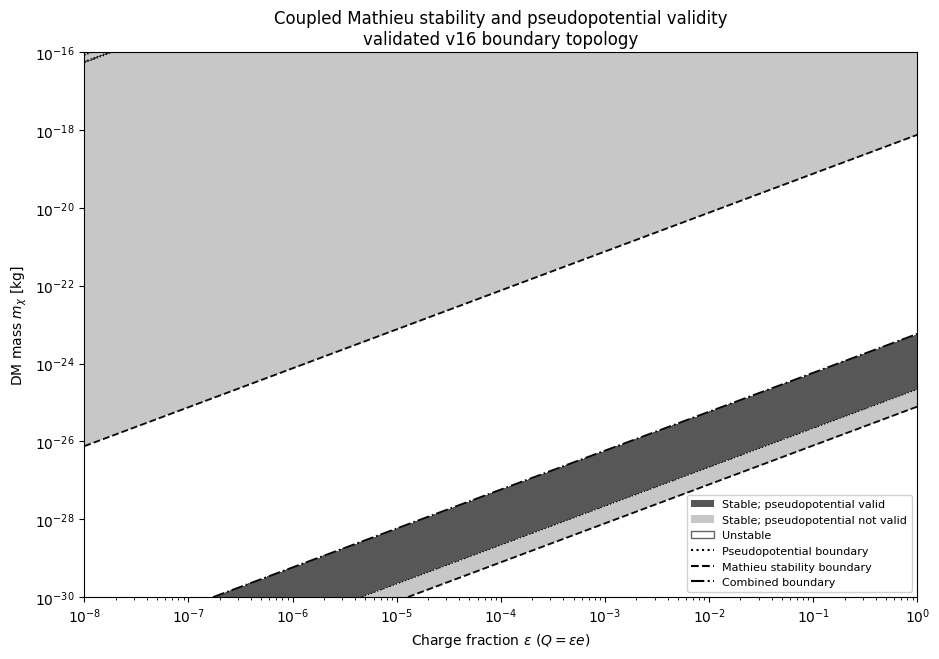

Full grid: 1296 points
Validated pseudopotential-valid points: 100
Trajectory solver calls outside valid region: 0 by construction


,m_dm_kg,eps,mathieu_stable,pseudopotential_valid,q_max,secular_over_rf,reference_class
0,1.000000e-30,2.351953e-07,True,True,0.022381,0.009468,2
1,1.000000e-30,3.981072e-07,True,True,0.037884,0.015005,2
2,1.000000e-30,6.738627e-07,True,True,0.064124,0.024320,2
3,1.000000e-30,1.140625e-06,True,True,0.108541,0.040047,2
4,1.000000e-30,1.930698e-06,True,True,0.183724,0.066643,2


In [4]:
def _log_edges(values):
    values = np.asarray(values, float)
    lv = np.log(values)
    edges = np.empty(values.size + 1)
    edges[1:-1] = np.exp(0.5 * (lv[:-1] + lv[1:]))
    edges[0] = np.exp(lv[0] - 0.5 * (lv[1] - lv[0]))
    edges[-1] = np.exp(lv[-1] + 0.5 * (lv[-1] - lv[-2]))
    return edges


def _full_grid_matrix(df, cfg, column):
    """Map rows onto the exact configured grid using stable log-space keys.

    Do not rely on exact float equality after CSV round trips.  The convergence
    runner now returns one canonical row per valid point, but this mapping also
    makes plots robust when inspecting older checkpoint files.
    """
    masses, eps = parameter_grid(cfg)
    Z = np.full((len(masses), len(eps)), np.nan, dtype=float)
    if column not in df.columns or df.empty:
        return masses, eps, Z
    mi = {round(math.log10(float(v)), 9): i for i, v in enumerate(masses)}
    ei = {round(math.log10(float(v)), 9): j for j, v in enumerate(eps)}
    for _, row in df.iterrows():
        try:
            m = float(row["m_dm_kg"]); e = float(row["eps"])
            i = mi.get(round(math.log10(m), 9)); j = ei.get(round(math.log10(e), 9))
            value = float(row[column])
        except (KeyError, TypeError, ValueError):
            continue
        if i is not None and j is not None:
            Z[i, j] = value
    return masses, eps, Z


def _valid_grid_mask(cfg):
    masses, eps = parameter_grid(cfg)
    V = np.zeros((len(masses), len(eps)), dtype=bool)
    mi = {round(math.log10(float(v)), 9): i for i, v in enumerate(masses)}
    ei = {round(math.log10(float(v)), 9): j for j, v in enumerate(eps)}
    for rec in valid_parameter_points(cfg).to_dict("records"):
        i = mi[round(math.log10(float(rec["m_dm_kg"])), 9)]
        j = ei[round(math.log10(float(rec["eps"])), 9)]
        V[i, j] = True
    return masses, eps, V


def _overlay_missing_or_zero(ax, cfg, Z, *, show_zero=False):
    masses, eps, V = _valid_grid_mask(cfg)
    missing = V & ~np.isfinite(Z)
    if np.any(missing):
        ii, jj = np.where(missing)
        ax.scatter(eps[jj], masses[ii], marker="x", s=34, linewidths=1.0,
                   color="black", zorder=8, label="valid point without finite central estimate")
    if show_zero:
        zeros = V & np.isfinite(Z) & (Z == 0.0)
        if np.any(zeros):
            ii, jj = np.where(zeros)
            ax.scatter(eps[jj], masses[ii], marker="o", s=30, facecolors="none",
                       edgecolors="black", linewidths=0.9, zorder=8, label="finite zero estimate")


def _draw_reference_background(ax, cfg):
    md, ed, stable, pseudo, _, _ = dense_validity_grid(cfg, n_mass=700, n_eps=700)
    classes = np.where(~stable, 0, np.where(pseudo, 2, 1)).T
    bg_cmap = ListedColormap(["white", "0.78", "0.34"])
    bg_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], bg_cmap.N)
    ax.pcolormesh(_log_edges(ed), _log_edges(md), classes, shading="flat",
                  cmap=bg_cmap, norm=bg_norm, zorder=0)
    e_line = np.geomspace(cfg.eps_min, cfg.eps_max, 1800)
    for boundary in mathieu_reference_boundaries(cfg):
        m_line = boundary["slope_kg"] * e_line
        visible = (m_line >= cfg.m_min_kg) & (m_line <= cfg.m_max_kg)
        if not np.any(visible):
            continue
        kind = boundary["kind"]
        linestyle = {"pseudopotential": ":", "stability": "--",
                     "stability+pseudopotential": "-."}[kind]
        lw = 0.9 if kind == "pseudopotential" else 1.35
        ax.plot(e_line[visible], m_line[visible], color="black",
                linestyle=linestyle, linewidth=lw, alpha=0.95, zorder=7)


def _validity_legend():
    return [
        Patch(facecolor="0.34", edgecolor="none", label="Stable; pseudopotential valid"),
        Patch(facecolor="0.78", edgecolor="none", label="Stable; pseudopotential not valid"),
        Patch(facecolor="white", edgecolor="0.4", label="Unstable"),
        Line2D([0], [0], color="black", linestyle=":", label="Pseudopotential boundary"),
        Line2D([0], [0], color="black", linestyle="--", label="Mathieu stability boundary"),
        Line2D([0], [0], color="black", linestyle="-.", label="Combined boundary"),
    ]


def _format_axes(ax, cfg, title):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(cfg.eps_min, cfg.eps_max); ax.set_ylim(cfg.m_min_kg, cfg.m_max_kg)
    ax.set_xlabel(r"Charge fraction $\epsilon$ ($Q=\epsilon e$)")
    ax.set_ylabel(r"DM mass $m_\chi$ [kg]")
    ax.set_title(title)


def plot_validity_reference(cfg, path):
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    ax.legend(handles=_validity_legend(), loc="lower right", fontsize=8, framealpha=0.9)
    _format_axes(ax, cfg, "Coupled Mathieu stability and pseudopotential validity\nvalidated v16 boundary topology")
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()


def plot_metric(df, cfg, column, title, colorbar_label, path, contours=True):
    masses, eps, Z = _full_grid_matrix(df, cfg, column)
    finite = np.isfinite(Z) & (Z > 0)
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    if finite.any():
        P = np.ma.masked_where(~finite, Z)
        vals = Z[finite]
        vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
        if vmax <= vmin * (1 + 1e-12):
            vmin /= np.sqrt(10.0); vmax *= np.sqrt(10.0)
        cmap = plt.get_cmap("viridis").copy(); cmap.set_bad((0, 0, 0, 0))
        im = ax.pcolormesh(_log_edges(eps), _log_edges(masses), P, shading="flat",
                           cmap=cmap, norm=LogNorm(vmin=vmin, vmax=vmax), zorder=3)
        fig.colorbar(im, ax=ax).set_label(colorbar_label)
        if contours and np.count_nonzero(finite) >= 10:
            L = np.log10(np.where(finite, Z, np.nan))
            lo, hi = np.nanmin(L), np.nanmax(L)
            if hi - lo > 0.4:
                levels = np.unique(np.round(np.linspace(lo, hi, 5), 1))
                cs = ax.contour(eps, masses, L, levels=levels, colors="black",
                                linewidths=0.75, zorder=6)
                ax.clabel(cs, fmt=lambda x: f"$10^{{{x:.1f}}}$", fontsize=8)
    _overlay_missing_or_zero(ax, cfg, Z, show_zero=True)
    handles = _validity_legend()[1:]
    extra_handles, extra_labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + extra_handles, loc="lower right", fontsize=8, framealpha=0.88)
    _format_axes(ax, cfg, title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()


def plot_convergence_quantity(df, cfg, column, title, label, path, vmax=None):
    masses, eps, Z = _full_grid_matrix(df, cfg, column)
    finite = np.isfinite(Z) & (Z >= 0)
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    if finite.any():
        P = np.ma.masked_where(~finite, Z)
        kwargs = {}
        if vmax is not None:
            kwargs.update(vmin=0.0, vmax=vmax)
        im = ax.pcolormesh(_log_edges(eps), _log_edges(masses), P, shading="flat",
                           cmap="viridis", zorder=3, **kwargs)
        fig.colorbar(im, ax=ax).set_label(label)
    _format_axes(ax, cfg, title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()


def plot_reliability(df, cfg, flag, title, path):
    masses, eps, Z = _full_grid_matrix(df, cfg, flag)
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    finite = np.isfinite(Z)
    if finite.any():
        P = np.ma.masked_where(~finite, Z.astype(float))
        cmap = ListedColormap(["0.85", "tab:green"])
        norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
        ax.pcolormesh(_log_edges(eps), _log_edges(masses), P, shading="flat",
                      cmap=cmap, norm=norm, zorder=3)
    ax.legend(handles=[Patch(facecolor="tab:green", label="passes all tests"),
                       Patch(facecolor="0.85", label="fails >=1 required test")],
              loc="lower right", fontsize=8)
    _format_axes(ax, cfg, title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()


def plot_relative_error(df, cfg, column, title, path, cap_pct=50.0):
    masses, eps, Z = _full_grid_matrix(df, cfg, column)
    Zpct = 100.0 * Z
    finite = np.isfinite(Zpct) & (Zpct >= 0)
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    if finite.any():
        # Saturate at the unresolved/noisy boundary so the useful 0-50%
        # structure remains visible; exact uncapped values remain in the CSV.
        P = np.ma.masked_where(~finite, np.minimum(Zpct, cap_pct))
        im = ax.pcolormesh(_log_edges(eps), _log_edges(masses), P, shading="flat",
                           cmap="viridis", vmin=0.0, vmax=cap_pct, zorder=3)
        fig.colorbar(im, ax=ax).set_label(
            f"Monte Carlo relative standard error [%] (>= {cap_pct:g}% saturated)"
        )
    _overlay_missing_or_zero(ax, cfg, Z, show_zero=False)
    _format_axes(ax, cfg, title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()


def plot_classification(df, cfg, code_column, title, path):
    masses, eps, Z = _full_grid_matrix(df, cfg, code_column)
    finite = np.isfinite(Z)
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    if finite.any():
        P = np.ma.masked_where(~finite, Z.astype(float))
        # 0 unresolved, 1 noisy, 2 support_unresolved, 3 estimated,
        # 4 well_converged, 5 precision_certified.
        cmap = ListedColormap(["0.30", "tab:red", "tab:purple", "tab:orange", "tab:blue", "tab:green"])
        norm = BoundaryNorm(np.arange(-0.5, 6.5, 1.0), cmap.N)
        ax.pcolormesh(_log_edges(eps), _log_edges(masses), P, shading="flat",
                      cmap=cmap, norm=norm, zorder=3)
    _overlay_missing_or_zero(ax, cfg, Z, show_zero=False)
    handles = [
        Patch(facecolor="tab:green", label="precision certified (<=5% + support + numerical audits)"),
        Patch(facecolor="tab:blue", label="well converged (<=10% + support + numerical audits)"),
        Patch(facecolor="tab:orange", label="estimated (<=20%, support bounded)"),
        Patch(facecolor="tab:purple", label="support unresolved (finite rate, b tail open)"),
        Patch(facecolor="tab:red", label="noisy (20-50%, support bounded)"),
        Patch(facecolor="0.30", label="unresolved (>50% / failure / nonfinite)"),
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=7.2, framealpha=0.92)
    _format_axes(ax, cfg, title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()

def plot_precision_certified_metric(df, cfg, rate_column, class_code_column, title, colorbar_label, path):
    """Show certified rates without mislabeling finite non-certified points as missing."""
    masses, eps, R = _full_grid_matrix(df, cfg, rate_column)
    _, _, C = _full_grid_matrix(df, cfg, class_code_column)
    _, _, V = _valid_grid_mask(cfg)
    finite_rate = V & np.isfinite(R)
    certified = finite_rate & np.isfinite(C) & (C == 5)
    noncert = finite_rate & ~certified
    missing = V & ~finite_rate
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    if np.any(noncert):
        status = np.ma.masked_where(~noncert, np.ones_like(R))
        ax.pcolormesh(_log_edges(eps), _log_edges(masses), status, shading="flat",
                      cmap=ListedColormap(["0.72"]), vmin=0.5, vmax=1.5, zorder=2.5)
    if np.any(certified):
        P = np.ma.masked_where(~certified, R)
        vals = R[certified]
        vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
        if vmax <= vmin * (1 + 1e-12): vmin /= np.sqrt(10.0); vmax *= np.sqrt(10.0)
        im = ax.pcolormesh(_log_edges(eps), _log_edges(masses), P, shading="flat",
                           cmap="viridis", norm=LogNorm(vmin=vmin, vmax=vmax), zorder=3)
        fig.colorbar(im, ax=ax).set_label(colorbar_label)
    if np.any(missing):
        ii, jj = np.where(missing)
        ax.scatter(eps[jj], masses[ii], marker="x", s=34, linewidths=1.0, color="black", zorder=8)
    handles = _validity_legend()[1:] + [
        Patch(facecolor="0.72", edgecolor="none", label="finite central estimate; not precision certified"),
        Line2D([0], [0], color="black", marker="x", linestyle="None", label="valid point without finite central estimate"),
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=7.5, framealpha=0.9)
    _format_axes(ax, cfg, title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()

def plot_numerical_failure_mode(df, cfg, code_column, title, path):
    """Show a numerical limiter, or explicitly why the numerical audit was not run."""
    masses, eps, Z = _full_grid_matrix(df, cfg, code_column)
    finite = np.isfinite(Z)
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    if finite.any():
        P = np.ma.masked_where(~finite, Z.astype(float))
        cmap = ListedColormap([
            "0.82", "0.35", "tab:blue", "tab:orange", "tab:green",
            "tab:red", "tab:purple", "tab:brown", "0.15", "tab:pink"
        ])
        norm = BoundaryNorm(np.arange(-0.5, 10.5, 1.0), cmap.N)
        ax.pcolormesh(_log_edges(eps), _log_edges(masses), P, shading="flat", cmap=cmap, norm=norm, zorder=3)
    legend_order = [1,2,3,4,5,6,7,9,0,8]
    facecolors = ["0.35","tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","tab:pink","0.82","0.15"]
    handles = [Patch(facecolor=c, label=NUMERICAL_FAILURE_LABELS[k]) for k,c in zip(legend_order,facecolors)]
    ax.legend(handles=handles, loc="lower right", fontsize=7.0, framealpha=0.92, ncol=2)
    _format_axes(ax, cfg, title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()

def plot_support_status(df, cfg, path):
    status_to_code = {
        "converged": 0,
        "tail_noise_limited": 1,
        "support_unresolved_max_factor": 2,
        "max_factor_reached": 2,
        "geometry_limited": 3,
        "in_progress": 4,
    }
    tmp = df.copy()
    tmp["_support_status_code"] = [status_to_code.get(str(x), 5) for x in tmp.get("adaptive_bmax_status", "")]
    masses, eps, Z = _full_grid_matrix(tmp, cfg, "_support_status_code")
    finite=np.isfinite(Z)
    fig,ax=plt.subplots(figsize=(9.5,6.7)); _draw_reference_background(ax,cfg)
    cmap=ListedColormap(["tab:green","tab:orange","tab:red","tab:purple","tab:blue","0.35"])
    norm=BoundaryNorm(np.arange(-0.5,6.5,1),cmap.N)
    if finite.any():
        ax.pcolormesh(_log_edges(eps),_log_edges(masses),np.ma.masked_where(~finite,Z),shading="flat",cmap=cmap,norm=norm,zorder=3)
    labels=["converged","tail_noise_limited","max_factor_reached","geometry_limited","in_progress","other/not audited"]
    ax.legend(handles=[Patch(facecolor=cmap.colors[i],label=labels[i]) for i in range(6)],loc="lower right",fontsize=7.2,framealpha=0.92)
    _format_axes(ax,cfg,"Adaptive impact-parameter support status")
    fig.tight_layout(); fig.savefig(path,dpi=180); plt.show()


def flatten_adaptive_b_history(df):
    """Create a reusable per-support diagnostic table from checkpoint JSON history."""
    rows=[]
    for _,r in df.iterrows():
        try: hist=json.loads(str(r.get("adaptive_bmax_history","[]")))
        except Exception: hist=[]
        if not isinstance(hist,list): continue
        for j,h in enumerate(hist):
            if not isinstance(h,dict): continue
            rec={"m_dm_kg":r.get("m_dm_kg"),"eps":r.get("eps"),"history_index":j,
                 "support_factor":h.get("support_factor",np.nan),"annulus_n":h.get("annulus_n",np.nan),
                 "decision":h.get("decision",h.get("source","legacy")),"clipped":h.get("clipped",False)}
            for lab in ("phonon","ge1","exact_M"):
                mm=h.get("metrics",{}).get(lab,{}) if isinstance(h.get("metrics",{}),dict) else {}
                for key in ("ann1_mean","ann1_se","ann2_mean","ann2_se","frac_mean","frac_lower","frac_upper"):
                    rec[f"{lab}_{key}"]=mm.get(key,np.nan)
            rows.append(rec)
    return pd.DataFrame(rows)


def plot_tail_history_representatives(history_df, audit_df, path, n_points=6):
    """Plot tail-fraction evolution for the most demanding support-repair points."""
    if history_df.empty: return
    candidates=audit_df.copy()
    candidates["_tail"] = pd.to_numeric(candidates.get("b_tail_phonon_fraction_upper"),errors="coerce")
    candidates["_factor"] = pd.to_numeric(candidates.get("adaptive_bmax_factor"),errors="coerce")
    candidates=candidates[np.isfinite(candidates["_factor"])].sort_values(["_factor","_tail"],ascending=False).head(n_points)
    if candidates.empty: return
    fig,ax=plt.subplots(figsize=(9.5,6.2))
    for _,r in candidates.iterrows():
        sel=history_df[np.isclose(history_df.m_dm_kg,float(r.m_dm_kg),rtol=1e-10)&np.isclose(history_df.eps,float(r.eps),rtol=1e-10)].copy()
        sel=sel[np.isfinite(pd.to_numeric(sel["phonon_frac_upper"],errors="coerce"))]
        if sel.empty: continue
        sel=sel.sort_values(["support_factor","annulus_n"])
        ax.plot(sel.support_factor,sel.phonon_frac_upper,marker="o",label=rf"$m={float(r.m_dm_kg):.1e},\ \epsilon={float(r.eps):.1e}$")
    ax.axhline(conv.b_tail_fraction_tol,linestyle="--",linewidth=1.0,label="tail tolerance")
    ax.set_xscale("log",base=2); ax.set_yscale("log")
    ax.set_xlabel(r"central support factor $B_{\rm final}/B_{\rm nominal}$")
    ax.set_ylabel(r"phonon tail 2-sigma upper fraction")
    ax.set_title("Adaptive-b tail history for representative difficult points")
    ax.legend(fontsize=7.0,framealpha=0.9)
    fig.tight_layout(); fig.savefig(path,dpi=180); plt.show()


def plot_observable_ratio(df, cfg, numerator, denominator, title, colorbar_label, path):
    masses, eps, N = _full_grid_matrix(df, cfg, numerator)
    _, _, D = _full_grid_matrix(df, cfg, denominator)
    _, _, V = _valid_grid_mask(cfg)
    ratio = np.full_like(N, np.nan, dtype=float)
    finite_inputs = V & np.isfinite(N) & np.isfinite(D)
    good = finite_inputs & (D > 0.0) & (N >= 0.0)
    ratio[good] = N[good] / D[good]
    fig, ax = plt.subplots(figsize=(9.5, 6.7))
    _draw_reference_background(ax, cfg)
    if np.any(good):
        P = np.ma.masked_where(~good, np.minimum(ratio, 1.0))
        im = ax.pcolormesh(_log_edges(eps), _log_edges(masses), P, shading="flat",
                           cmap="viridis", vmin=0.0, vmax=1.0, zorder=3)
        fig.colorbar(im, ax=ax).set_label(colorbar_label)
    missing = V & ~finite_inputs
    if np.any(missing):
        ii, jj = np.where(missing)
        ax.scatter(eps[jj], masses[ii], marker="x", s=34, linewidths=1.0,
                   color="black", zorder=8, label="missing central input")
    zero_den = finite_inputs & (D == 0.0)
    if np.any(zero_den):
        ii, jj = np.where(zero_den)
        ax.scatter(eps[jj], masses[ii], marker="o", s=30, facecolors="none",
                   edgecolors="black", linewidths=0.9, zorder=8, label="ratio undefined: denominator = 0")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles=handles, labels=labels, loc="lower right", fontsize=8, framealpha=0.9)
    _format_axes(ax, cfg, title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()


plot_validity_reference(cfg, OUTPUT / "mathieu_validity_reference.png")
valid_points = valid_parameter_points(cfg)
print(f"Full grid: {cfg.n_mass * cfg.n_eps} points")
print(f"Validated pseudopotential-valid points: {len(valid_points)}")
print(f"Trajectory solver calls outside valid region: 0 by construction")
display(valid_points.head())


def plot_asymptotic_status(df, cfg, path):
    status_to_code = {
        "candidate_bounded_all": 0,
        "decaying_above_tolerance": 1,
        "mixed_or_weak_decay": 2,
        "not_bounded": 3,
        "disabled": 4,
    }
    tmp=df.copy()
    tmp["_asymptotic_status_code"]=[status_to_code.get(str(x),5) for x in tmp.get("asymptotic_tail_status","")]
    masses,eps,Z=_full_grid_matrix(tmp,cfg,"_asymptotic_status_code")
    finite=np.isfinite(Z)
    fig,ax=plt.subplots(figsize=(9.5,6.7)); _draw_reference_background(ax,cfg)
    cmap=ListedColormap(["tab:green","tab:orange","tab:purple","tab:red","0.75","0.35"])
    norm=BoundaryNorm(np.arange(-0.5,6.5,1),cmap.N)
    if finite.any():
        ax.pcolormesh(_log_edges(eps),_log_edges(masses),np.ma.masked_where(~finite,Z),shading="flat",cmap=cmap,norm=norm,zorder=3)
    labels=["candidate bounded (diagnostic only)","decaying but > tail tolerance","mixed/weak decay","not bounded","disabled","no asymptotic analysis"]
    ax.legend(handles=[Patch(facecolor=cmap.colors[i],label=labels[i]) for i in range(6)],loc="lower right",fontsize=7.1,framealpha=0.92)
    _format_axes(ax,cfg,"Asymptotic impact-parameter tail diagnostic")
    fig.tight_layout(); fig.savefig(path,dpi=180); plt.show()


def plot_repair_action(df, cfg, path):
    actions=["none","tail_refine","geometry_repair","support_resume","numerical_upgrade","asymptotic_only","central"]
    amap={a:i for i,a in enumerate(actions)}
    tmp=df.copy()
    vals=[]
    for _,r in tmp.iterrows():
        a=str(r.get("support_repair_action",r.get("job_mode","none")))
        if a in ("", "nan", "None"): a="none"
        vals.append(amap.get(a,0))
    tmp["_repair_action_code"]=vals
    masses,eps,Z=_full_grid_matrix(tmp,cfg,"_repair_action_code")
    finite=np.isfinite(Z)
    fig,ax=plt.subplots(figsize=(9.5,6.7)); _draw_reference_background(ax,cfg)
    cmap=ListedColormap(["0.75","tab:orange","tab:purple","tab:blue","tab:green","tab:brown","tab:red"])
    norm=BoundaryNorm(np.arange(-0.5,len(actions)+0.5,1),cmap.N)
    if finite.any():
        ax.pcolormesh(_log_edges(eps),_log_edges(masses),np.ma.masked_where(~finite,Z),shading="flat",cmap=cmap,norm=norm,zorder=3)
    ax.legend(handles=[Patch(facecolor=cmap.colors[i],label=actions[i]) for i in range(len(actions))],loc="lower right",fontsize=7.0,framealpha=0.92,ncol=2)
    _format_axes(ax,cfg,"Checkpoint work performed / repair action")
    fig.tight_layout(); fig.savefig(path,dpi=180); plt.show()


## 3. Optional one staged trajectory diagnostic

The targeted production rerun below is the only expensive calculation enabled by default. The historical single-trajectory diagnostic is retained for manual debugging, but is disabled so that **Run All** does not spend solver time on a non-target point.

In [5]:
RUN_SINGLE_TRAJECTORY_DIAGNOSTIC = False

if RUN_SINGLE_TRAJECTORY_DIAGNOSTIC:
    example = dict(m_dm=1e-25, eps=0.1, speed=100.0, b=10e-6,
                   theta=1.0, alpha=2.0, psi=0.5)
    print("validity:", mathieu_metrics(example["m_dm"], example["eps"], cfg))
    print("regime:", classify_collision_regime(example["speed"], example["b"]))
    print("radii:", certify_radii(**example, cfg=cfg))
    diag = staged_single_sample(**example, cfg=cfg, ground=ground, seed=123)
    display(diag)
else:
    print("Single-trajectory diagnostic skipped (targeted rerun mode).")

Single-trajectory diagnostic skipped (targeted rerun mode).


## 4. Targeted direct-staged repair of the problematic points

This revision does **not** submit the full set of 100 pseudopotential-valid points to the convergence runner. It first loads the existing canonical full-grid checkpoint (falling back to the existing convergence-audit or staged-event-rate CSV if needed), makes a one-time backup, and then temporarily exposes only the eight entries in `PROBLEM_POINTS` to `run_converged_valid_grid`.

The targeted runner uses `central_estimator_mode="direct"` and a fresh seed. Its partial results are checkpointed separately, so interrupting the run does not damage the existing 100-point result. When the targeted run completes, successful finite/nonnegative direct central estimates replace only their matching rows. Every other row is preserved from the prior result.

Set `RESET_TARGETED_RERUN=True` only when you intentionally want to throw away the separate targeted partial checkpoint and restart those eight jobs from scratch.

### Robust targeted worker run

The same subprocess watchdog machinery is retained, but at most the eight problematic points are queued. A targeted job can therefore be resumed independently of the full-grid checkpoint. The canonical full-grid checkpoint is updated only after the merge step, and a backup of the pre-rerun checkpoint is kept in `outputs/`.

In [6]:

# -----------------------------------------------------------------------------
# Targeted direct-staged rerun and safe merge into the existing full-grid result
# -----------------------------------------------------------------------------
def _target_grid_key(m_dm_kg, eps):
    return (round(math.log10(float(m_dm_kg)), 9), round(math.log10(float(eps)), 9))


def _row_has_finite_nonnegative_central(row):
    vals = []
    for name in ("phonon_rate_s", "event_rate_ge1_s", "event_rate_exact_M_s"):
        try:
            vals.append(float(row.get(name, np.nan)))
        except (TypeError, ValueError):
            return False
    return bool(np.all(np.isfinite(vals)) and np.all(np.asarray(vals) >= 0.0))


def _load_existing_full_result():
    candidates = [
        CONVERGENCE_CHECKPOINT,
        OUTPUT / "staged_event_rate_convergence_audit.csv",
        OUTPUT / "staged_event_rate.csv",
    ]
    for path in candidates:
        if path.exists() and path.stat().st_size > 0:
            print("Preserving existing full-grid results from:", path)
            return path, pd.read_csv(path)
    raise FileNotFoundError(
        "Targeted rerun mode needs the existing full-grid result so the fine rows can be preserved. "
        "Place the previous outputs/ folder beside this notebook (preferred checkpoint: "
        f"{CONVERGENCE_CHECKPOINT.name}) and rerun."
    )


if not TARGETED_RERUN_ONLY:
    raise RuntimeError(
        "This notebook copy is intentionally configured for targeted reruns only. "
        "Use the original full-staged notebook for another all-valid-points pass."
    )

base_path, base_df = _load_existing_full_result()
full_valid_df = valid_parameter_points(cfg).copy().reset_index(drop=True)
full_valid_records = full_valid_df.to_dict("records")
valid_keys = {_target_grid_key(r["m_dm_kg"], r["eps"]) for r in full_valid_records}
problem_keys = {_target_grid_key(p["m_dm_kg"], p["eps"]) for p in PROBLEM_POINTS}

not_valid = problem_keys - valid_keys
if not_valid:
    raise RuntimeError(f"At least one requested problem point is not on the current valid grid: {sorted(not_valid)}")

# Canonicalize the prior result by current-grid key without changing any surviving row.
# The existing v2026-08-14.1 checkpoint should already be one-row-per-valid-point;
# this explicit map is only a guard against stale rows from older files.
base_map = {}
for rec in base_df.to_dict("records"):
    try:
        key = _target_grid_key(rec["m_dm_kg"], rec["eps"])
    except Exception:
        continue
    if key in valid_keys:
        base_map[key] = rec

missing_base = valid_keys - set(base_map)
if missing_base:
    raise RuntimeError(
        f"Existing result is missing {len(missing_base)} current valid-grid rows. "
        "Refusing targeted merge because non-target results could be lost."
    )

# Make a one-time backup before any successful targeted rows are merged.
if not TARGETED_BACKUP.exists():
    shutil.copy2(base_path, TARGETED_BACKUP)
    print("Saved pre-rerun backup:", TARGETED_BACKUP)
else:
    print("Pre-rerun backup already exists:", TARGETED_BACKUP)

if RESET_TARGETED_RERUN and TARGETED_RERUN_CHECKPOINT.exists():
    TARGETED_RERUN_CHECKPOINT.unlink()
    print("Deleted targeted partial checkpoint for a clean restart:", TARGETED_RERUN_CHECKPOINT)

# Resolve the target coordinates against the exact configured grid. This avoids
# float-roundtrip mismatches and keeps the runner's point ordinals deterministic.
problem_order = {
    _target_grid_key(p["m_dm_kg"], p["eps"]): i for i, p in enumerate(PROBLEM_POINTS)
}
_original_module_valid_parameter_points = mcp.valid_parameter_points


def _targeted_valid_parameter_points(local_cfg):
    full = _original_module_valid_parameter_points(local_cfg).copy()
    keys = [_target_grid_key(m, e) for m, e in zip(full["m_dm_kg"], full["eps"])]
    mask = np.asarray([k in problem_keys for k in keys], dtype=bool)
    out = full.loc[mask].copy()
    out["_target_order"] = [problem_order[_target_grid_key(m, e)] for m, e in zip(out["m_dm_kg"], out["eps"])]
    return out.sort_values("_target_order").drop(columns="_target_order").reset_index(drop=True)

# Force a genuinely direct staged central estimate for the targeted validation
# and use a fresh seed. All other reliable-profile numerical/support settings are
# kept unchanged.
target_cfg = replace(cfg, seed=int(TARGET_DIRECT_SEED))
target_conv = replace(conv, central_estimator_mode="direct")

t0 = time.time()
try:
    # run_converged_valid_grid resolves this name from the shared module globals,
    # so the temporary patch limits the parent queue to the eight target points.
    mcp.valid_parameter_points = _targeted_valid_parameter_points
    targeted_df = mcp.run_converged_valid_grid(
        target_cfg, ground, target_conv,
        progress=SHOW_LIVE_PROGRESS,
        checkpoint_path=TARGETED_RERUN_CHECKPOINT,
        resume=True,
        max_workers=min(PARALLEL_WORKERS, len(PROBLEM_POINTS)),
        parallel_backend=PARALLEL_BACKEND,
        point_timeout_s=POINT_WALLTIME_S,
        heartbeat_s=HEARTBEAT_S,
    )
finally:
    # Always restore the full-grid validity function, even after an exception.
    mcp.valid_parameter_points = _original_module_valid_parameter_points

print(f"Targeted runtime this session: {time.time() - t0:.2f} s")
targeted_df.to_csv(TARGETED_RERUN_RESULTS, index=False)
print("Targeted direct results:", TARGETED_RERUN_RESULTS)

# Merge policy: a problem row is replaced only by a finite, nonnegative direct
# staged result. A failed/incomplete targeted attempt never deletes the previous
# row. Non-target rows are copied from base_map without modification.
target_map = {}
for rec in targeted_df.to_dict("records"):
    try:
        key = _target_grid_key(rec["m_dm_kg"], rec["eps"])
    except Exception:
        continue
    if key in problem_keys:
        target_map[key] = rec

merged_map = dict(base_map)
merge_report = []
for p in PROBLEM_POINTS:
    key = _target_grid_key(p["m_dm_kg"], p["eps"])
    old = base_map[key]
    new = target_map.get(key)
    new_estimator = "" if new is None else str(new.get("central_estimator", ""))
    new_ok = bool(
        new is not None
        and _row_has_finite_nonnegative_central(new)
        and new_estimator == "direct_staged"
    )
    if new_ok:
        merged_map[key] = new
        action = "replaced_with_fresh_direct_staged"
    else:
        action = "kept_previous_row_targeted_attempt_incomplete_or_invalid"

    merge_report.append({
        "m_dm_kg": p["m_dm_kg"],
        "eps": p["eps"],
        "reason": p["reason"],
        "merge_action": action,
        "new_central_estimator": new_estimator,
        "new_worker_failure": np.nan if new is None else new.get("worker_failure", np.nan),
        "new_wallclock_timeout": np.nan if new is None else new.get("wallclock_timeout", np.nan),
        "old_phonon_rate_s": old.get("phonon_rate_s", np.nan),
        "new_phonon_rate_s": np.nan if new is None else new.get("phonon_rate_s", np.nan),
        "old_event_rate_ge1_s": old.get("event_rate_ge1_s", np.nan),
        "new_event_rate_ge1_s": np.nan if new is None else new.get("event_rate_ge1_s", np.nan),
        "old_event_rate_exact_M_s": old.get("event_rate_exact_M_s", np.nan),
        "new_event_rate_exact_M_s": np.nan if new is None else new.get("event_rate_exact_M_s", np.nan),
    })

# Reconstruct the full canonical table in the exact current valid-grid order.
merged_records = []
for rec in full_valid_records:
    key = _target_grid_key(rec["m_dm_kg"], rec["eps"])
    merged_records.append(merged_map[key])
audit_df = pd.DataFrame(merged_records)

# Only now update the canonical checkpoint. Fine/non-target rows came directly
# from the prior base result; only accepted targeted rows can differ.
audit_df.to_csv(CONVERGENCE_CHECKPOINT, index=False)
merge_report_df = pd.DataFrame(merge_report)
merge_report_df.to_csv(TARGETED_MERGE_REPORT, index=False)
print("Updated canonical checkpoint:", CONVERGENCE_CHECKPOINT)
print("Targeted merge report:", TARGETED_MERGE_REPORT)
display(merge_report_df)

# Add/refresh the six-level quality classification.  This also upgrades old
# checkpoint rows without forcing completed central estimates to be rerun.
audit_df = add_result_classifications(audit_df, conv)

# Canonical-grid integrity check.  The runner must return exactly one row for
# each CURRENT pseudopotential-valid point; old duplicate/stale checkpoint rows
# are not allowed to inflate the denominator.
_expected_valid = valid_parameter_points(cfg)
_expected_n = len(_expected_valid)
_actual_unique = len({(round(math.log10(float(r.m_dm_kg)), 9), round(math.log10(float(r.eps)), 9)) for _, r in audit_df.iterrows()})
_central_complete = (
    np.isfinite(pd.to_numeric(audit_df["phonon_rate_s"], errors="coerce"))
    & np.isfinite(pd.to_numeric(audit_df["event_rate_ge1_s"], errors="coerce"))
    & np.isfinite(pd.to_numeric(audit_df["event_rate_exact_M_s"], errors="coerce"))
)
print(f"Current-grid integrity: rows={len(audit_df)}, unique={_actual_unique}, expected valid={_expected_n}")
print(f"Finite central estimates: {int(_central_complete.sum())}/{_expected_n}; missing/failed central estimates: {int((~_central_complete).sum())}")
if len(audit_df) != _expected_n or _actual_unique != _expected_n:
    raise RuntimeError("Current-grid table is not one-row-per-valid-point; do not plot this result.")

# Add worst-case numerical shifts and the identity of the limiting numerical test.
audit_df = add_numerical_failure_diagnostics(audit_df, conv)
audit_df = add_asymptotic_tail_diagnostics(audit_df, conv)

# Observable ratios diagnose whether the signal is predominantly weak/single-phonon.
def _safe_ratio(num, den):
    num = pd.to_numeric(num, errors="coerce").to_numpy(float)
    den = pd.to_numeric(den, errors="coerce").to_numpy(float)
    out = np.full(num.shape, np.nan, dtype=float)
    good = np.isfinite(num) & np.isfinite(den) & (den > 0.0) & (num >= 0.0)
    out[good] = num[good] / den[good]
    return out

audit_df["ratio_ge1_to_phonon"] = _safe_ratio(audit_df["event_rate_ge1_s"], audit_df["phonon_rate_s"])
audit_df["ratio_exact_M_to_ge1"] = _safe_ratio(audit_df["event_rate_exact_M_s"], audit_df["event_rate_ge1_s"])

AUDIT_CSV = OUTPUT / "staged_event_rate_convergence_audit.csv"
CLASSIFIED_CSV = OUTPUT / "staged_event_rate_classified.csv"
audit_df.to_csv(AUDIT_CSV, index=False)
audit_df.to_csv(CLASSIFIED_CSV, index=False)
# Backward-compatible central-estimate filename. It contains valid points only.
audit_df.to_csv(OUTPUT / "staged_event_rate.csv", index=False)

# Strict precision-certified table retained for backward compatibility.
reliable_df = audit_df.copy()
metric_flags = {
    "phonon_rate_s": "reliable_phonon",
    "event_rate_ge1_s": "reliable_ge1",
    "event_rate_exact_M_s": "reliable_exact_M",
}
for metric, flag in metric_flags.items():
    reliable_df.loc[~reliable_df[flag].astype(bool), metric] = np.nan
RELIABLE_CSV = OUTPUT / "staged_event_rate_reliable.csv"
reliable_df.to_csv(RELIABLE_CSV, index=False)

# Six-level classification summary for each observable.
classification_rows = []
for observable, label in [
    ("Ndot_ph", "phonon"),
    ("Gamma_ge1", "ge1"),
    (f"Gamma_M{cfg.exact_phonon_number}", "exact_M"),
]:
    counts = audit_df[f"{label}_classification"].value_counts()
    for code in range(5, -1, -1):
        cls = RESULT_CLASS_LABELS[code]
        classification_rows.append({
            "observable": observable,
            "classification": cls,
            "points": int(counts.get(cls, 0)),
            "valid_points": _expected_n,
            "fraction": float(counts.get(cls, 0) / _expected_n) if _expected_n else np.nan,
        })
classification_summary = pd.DataFrame(classification_rows)
classification_summary.to_csv(OUTPUT / "staged_classification_summary.csv", index=False)
classification_wide = (classification_summary
    .pivot(index="observable", columns="classification", values="points")
    .fillna(0).astype(int)
    .reindex(columns=[RESULT_CLASS_LABELS[i] for i in range(5, -1, -1)], fill_value=0))
classification_wide["valid_points"] = _expected_n
classification_wide.to_csv(OUTPUT / "staged_classification_summary_wide.csv")
print("Six-level quality distribution (this is the table to use for estimated/noisy/unresolved counts):")
display(classification_wide)

upgrade_candidates = {
    "phonon": int(audit_df.get("phonon_needs_secondary_audit", pd.Series(False, index=audit_df.index)).sum()),
    "Gamma_ge1": int(audit_df.get("ge1_needs_secondary_audit", pd.Series(False, index=audit_df.index)).sum()),
    f"Gamma_M{cfg.exact_phonon_number}": int(audit_df.get("exact_M_needs_secondary_audit", pd.Series(False, index=audit_df.index)).sum()),
}
print("Old checkpoint rows that could potentially be upgraded from estimated to well_converged after a secondary audit:")
print(upgrade_candidates)

# Keep the old precision-certification summary as a compact reference.
summary = pd.DataFrame({
    "observable": [r"Ndot_ph", r"Gamma_ge1", f"Gamma_M{cfg.exact_phonon_number}", "all_three"],
    "precision_certified_points": [
        int((audit_df.phonon_class_code == 5).sum()),
        int((audit_df.ge1_class_code == 5).sum()),
        int((audit_df.exact_M_class_code == 5).sum()),
        int((audit_df.overall_class_code == 5).sum()),
    ],
    "valid_points": _expected_n,
})
summary["fraction_precision_certified"] = summary["precision_certified_points"] / _expected_n
summary.to_csv(OUTPUT / "staged_reliability_summary.csv", index=False)
print("Strict 5% precision-certification summary. A zero here does NOT mean the points are unresolved; consult the six-level table above.")
display(summary)

print("Classification reasons (top 20 per observable):")
for _label in ("phonon", "ge1", "exact_M"):
    print(f"\n{_label}:")
    display(audit_df[f"{_label}_classification_reason"].value_counts(dropna=False).rename("count").to_frame().head(20))

# Flatten the adaptive-b history so the old/new annulus evidence can be inspected without rerunning trajectories.
TAIL_HISTORY_CSV = OUTPUT / "staged_adaptive_bmax_history.csv"
tail_history_df = flatten_adaptive_b_history(audit_df)
tail_history_df.to_csv(TAIL_HISTORY_CSV, index=False)
print("Adaptive-b history CSV:", TAIL_HISTORY_CSV, "rows=", len(tail_history_df))


# Status-aware support-repair summary. This confirms that the notebook reused the
# old checkpoint rather than restarting all central Monte Carlo samples.
if "job_mode" in audit_df.columns:
    print("Work modes represented in the canonical checkpoint:")
    display(audit_df["job_mode"].fillna("none").value_counts().rename("count").to_frame())
if "adaptive_bmax_status" in audit_df.columns:
    print("Adaptive-b support outcomes:")
    display(audit_df["adaptive_bmax_status"].fillna("not_audited").value_counts().rename("count").to_frame())
if "asymptotic_tail_status" in audit_df.columns:
    print("Asymptotic-tail diagnostic outcomes (diagnostic only; never an automatic support pass):")
    display(audit_df["asymptotic_tail_status"].fillna("not_analyzed").value_counts().rename("count").to_frame())

print("Audit/classified CSV:", CLASSIFIED_CSV)
print("Precision-certified-only CSV:", RELIABLE_CSV)
print("Failure modes:")
display(audit_df["reliability_failures"].value_counts(dropna=False).rename("count").to_frame().head(20))
display(audit_df.head())


Preserving existing full-grid results from: c:\Users\potha\VS Code\DM Simulation\.vscode\outputs\staged_convergence_valid_partial_reliable.csv
Saved pre-rerun backup: c:\Users\potha\VS Code\DM Simulation\.vscode\outputs\staged_convergence_valid_partial_reliable_before_problem_rerun.csv
Pending work: 8 of 8 valid points (central=8); workers=8; backend=subprocess; point_timeout=1800.0s; segment_timeout=30.0s.
  started central point 1/8 [pid 70032]: m=1.000e-16, eps=1.000e-08
  started central point 2/8 [pid 83920]: m=3.981e-25, eps=3.490e-01
  started central point 3/8 [pid 37908]: m=3.981e-25, eps=5.908e-01
  started central point 4/8 [pid 83396]: m=1.000e-30, eps=6.739e-07
  started central point 5/8 [pid 79844]: m=1.585e-25, eps=5.908e-01
  started central point 6/8 [pid 81488]: m=3.981e-25, eps=1.000e+00
  started central point 7/8 [pid 79492]: m=2.512e-24, eps=5.908e-01
  started central point 8/8 [pid 84960]: m=2.512e-24, eps=1.000e+00
[heartbeat] 8 workers running; 0 jobs queued.

,m_dm_kg,eps,reason,merge_action,new_central_estimator,new_worker_failure,new_wallclock_timeout,old_phonon_rate_s,new_phonon_rate_s,old_event_rate_ge1_s,new_event_rate_ge1_s,old_event_rate_exact_M_s,new_event_rate_exact_M_s
0,1.000000e-16,1.000000e-08,missing staged central estimate,kept_previous_row_targeted_attempt_incomplete_...,nan,False,True,NaN,NaN,NaN,NaN,NaN,NaN
1,3.981072e-25,3.490255e-01,negative staged Gamma_1,kept_previous_row_targeted_attempt_incomplete_...,nan,False,True,1.737871e+02,NaN,2.163042e+00,NaN,-5.609573e-01,NaN
2,3.981072e-25,5.907838e-01,negative staged Gamma_ge1,kept_previous_row_targeted_attempt_incomplete_...,nan,False,True,9.448066e+01,NaN,-3.726479e+00,NaN,2.831797e+00,NaN
3,1.000000e-30,6.738627e-07,staged/screening ratio about 23.9 for all obse...,replaced_with_fresh_direct_staged,direct_staged,False,False,3.881588e-11,5.079065e-12,3.881587e-11,5.079086e-12,3.881586e-11,5.079063e-12
4,1.584893e-25,5.907838e-01,event-rate staged/screening ratios about 22-25,kept_previous_row_targeted_attempt_incomplete_...,nan,False,True,8.955858e+01,NaN,2.163340e+01,NaN,1.944583e+01,NaN
5,3.981072e-25,1.000000e+00,event-rate staged/screening ratios about 25 an...,kept_previous_row_targeted_attempt_incomplete_...,nan,False,True,9.985100e+01,NaN,4.704827e+01,NaN,4.528007e+01,NaN
6,2.511886e-24,5.907838e-01,event-rate staged/screening ratios about 170 a...,kept_previous_row_targeted_attempt_incomplete_...,nan,False,True,1.015190e+03,NaN,7.020421e+02,NaN,6.780804e+02,NaN
7,2.511886e-24,1.000000e+00,phonon ratio about 15.7 and event-rate ratios ...,kept_previous_row_targeted_attempt_incomplete_...,nan,False,True,2.275060e+03,NaN,1.891994e+03,NaN,1.692281e+03,NaN


Current-grid integrity: rows=100, unique=100, expected valid=100
Finite central estimates: 99/100; missing/failed central estimates: 1
Six-level quality distribution (this is the table to use for estimated/noisy/unresolved counts):


classification,precision_certified,well_converged,estimated,support_unresolved,noisy,unresolved,valid_points
observable,,,,,,,
Gamma_M1,0,6,23,55,6,10,100
Gamma_ge1,0,6,24,55,6,9,100
Ndot_ph,0,3,39,57,0,1,100


Old checkpoint rows that could potentially be upgraded from estimated to well_converged after a secondary audit:
{'phonon': 2, 'Gamma_ge1': 0, 'Gamma_M1': 0}
Strict 5% precision-certification summary. A zero here does NOT mean the points are unresolved; consult the six-level table above.


...

Asymptotic-tail diagnostic outcomes (diagnostic only; never an automatic support pass):


,count
asymptotic_tail_status,
not_bounded,64
mixed_or_weak_decay,28
decaying_above_tolerance,8


Audit/classified CSV: c:\Users\potha\VS Code\DM Simulation\.vscode\outputs\staged_event_rate_classified.csv
Precision-certified-only CSV: c:\Users\potha\VS Code\DM Simulation\.vscode\outputs\staged_event_rate_reliable.csv
Failure modes:


,count
reliability_failures,
MC:phonon;b-tail:phonon;MC:ge1;b-tail:ge1;MC:exact_M;b-tail:exact_M,57
point-wallclock-timeout-during-support-audit,21
MC:phonon;MC:ge1;MC:exact_M,15
MC:phonon;MC:ge1;b-tail:ge1;MC:exact_M;b-tail:exact_M,6
point-wallclock-timeout-before-central,1


,m_dm_kg,eps,mathieu_stable,pseudopotential_valid,q_max,secular_over_rf,reference_class,effective_samples,adaptive_stop_reason,mean_nfev,...,max_numerical_ge1_relative_upper,dominant_numerical_ge1,dominant_numerical_ge1_code,dominant_numerical_ge1_pass,max_numerical_exact_M_relative_upper,dominant_numerical_exact_M,dominant_numerical_exact_M_code,dominant_numerical_exact_M_pass,ratio_ge1_to_phonon,ratio_exact_M_to_ge1
0,1.000000e-30,2.351953e-07,True,True,0.022381,0.009468,2,2048,max_samples,0.0,...,NaN,blocked_by_support,9,False,NaN,blocked_by_support,9,False,0.999999,1.000001
1,1.000000e-30,3.981072e-07,True,True,0.037884,0.015005,2,2048,max_samples,0.0,...,NaN,blocked_by_support,9,False,NaN,blocked_by_support,9,False,1.000000,1.000000
2,1.000000e-30,6.738627e-07,True,True,0.064124,0.024320,2,2048,max_samples,0.0,...,NaN,blocked_by_support,9,False,NaN,blocked_by_support,9,False,1.000004,0.999995
3,1.000000e-30,1.140625e-06,True,True,0.108541,0.040047,2,2048,max_samples,0.0,...,NaN,blocked_by_support,9,False,NaN,blocked_by_support,9,False,0.999998,0.999998
4,1.000000e-30,1.930698e-06,True,True,0.183724,0.066643,2,2048,max_samples,0.0,...,NaN,blocked_by_support,9,False,NaN,blocked_by_support,9,False,0.999991,0.999991


## 5. Central-rate, uncertainty, classification, and support diagnostics

Each observable should be interpreted together with its central rate, Monte Carlo uncertainty, and six-level quality classification. Version 2026-08-13.2 additionally produces:

- **adaptive-$b_{\max}$ support repair:** previous central estimates and previous annulus summaries are reused; statistically ambiguous tails receive more samples at fixed support before any geometric expansion;
- **support-status diagnostics:** `converged`, `tail_noise_limited`, `support_unresolved_max_factor`, or `geometry_limited`;
- **adaptive-$b$ history CSV:** every retained support factor, annulus sample size, mean/lower/upper tail fraction, and repair decision;
- **dominant numerical-failure maps:** `far_outer`, `timestep`, `tolerances`, `stage_time`, `switch`, `ground`, `pass_all`, or `not_audited`;
- **fixed precision-certified maps:** finite but non-certified points are shown separately from genuinely missing central estimates;
- **observable-ratio maps:** $\Gamma_{\ge1}/\dot N_{\rm ph}$ and $\Gamma_M/\Gamma_{\ge1}$. For $M=1$, ratios near unity indicate a predominantly weak, one-phonon excitation regime.

The checkpoint remains canonicalized to exactly one row per current pseudopotential-valid grid point. A black `x` is reserved only for a valid point with no finite central estimate.


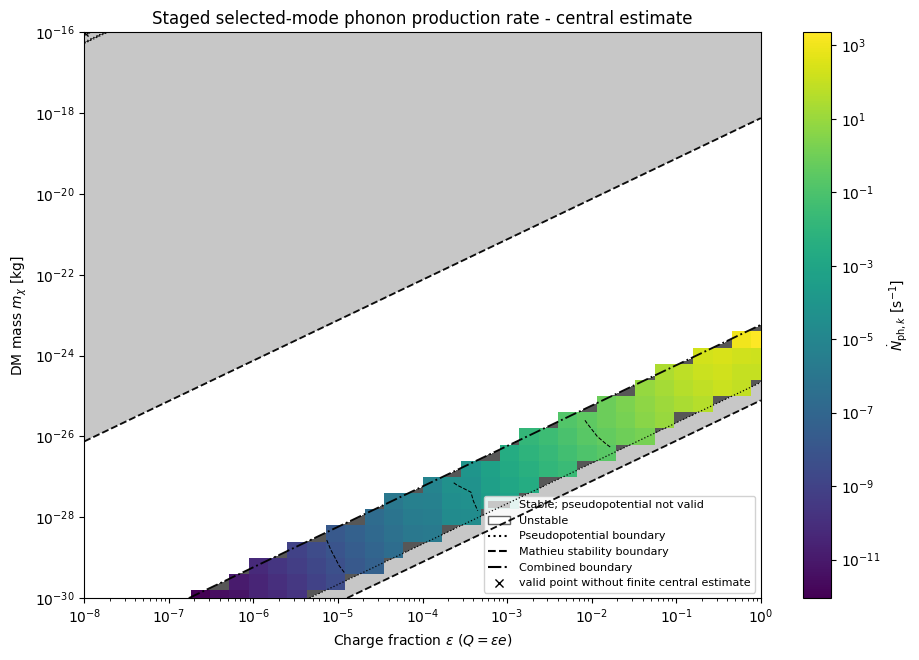

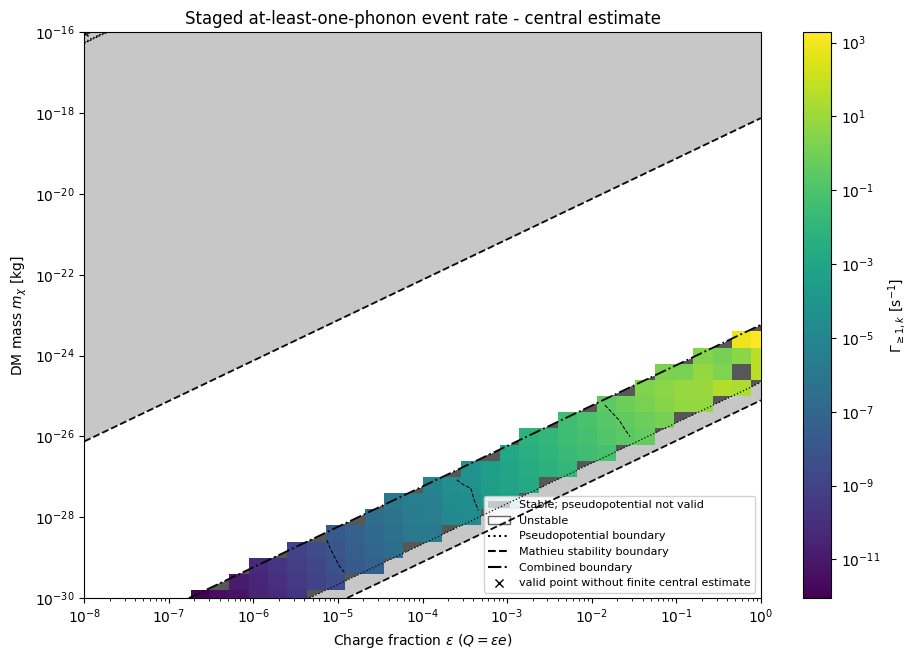

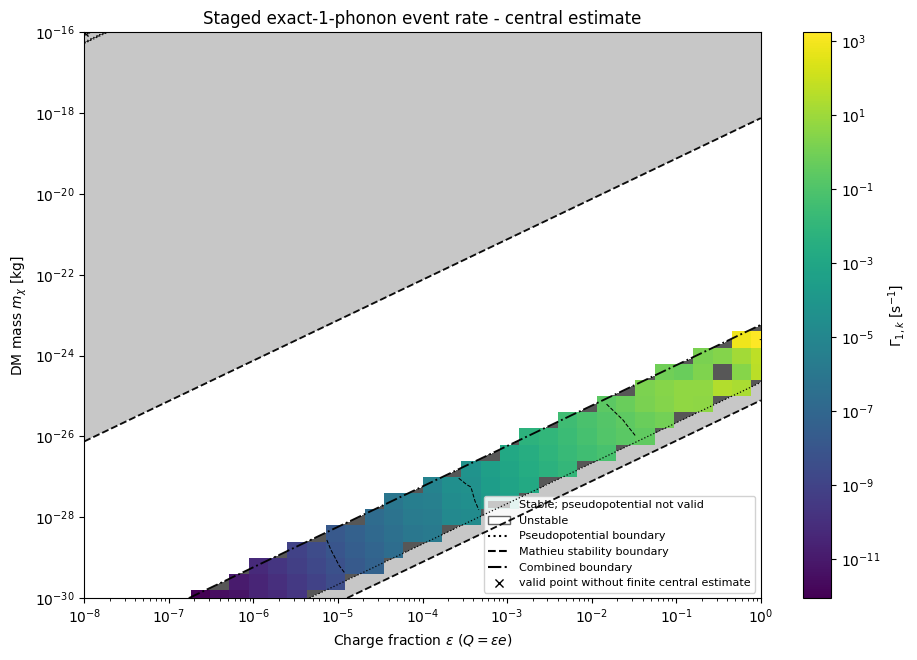

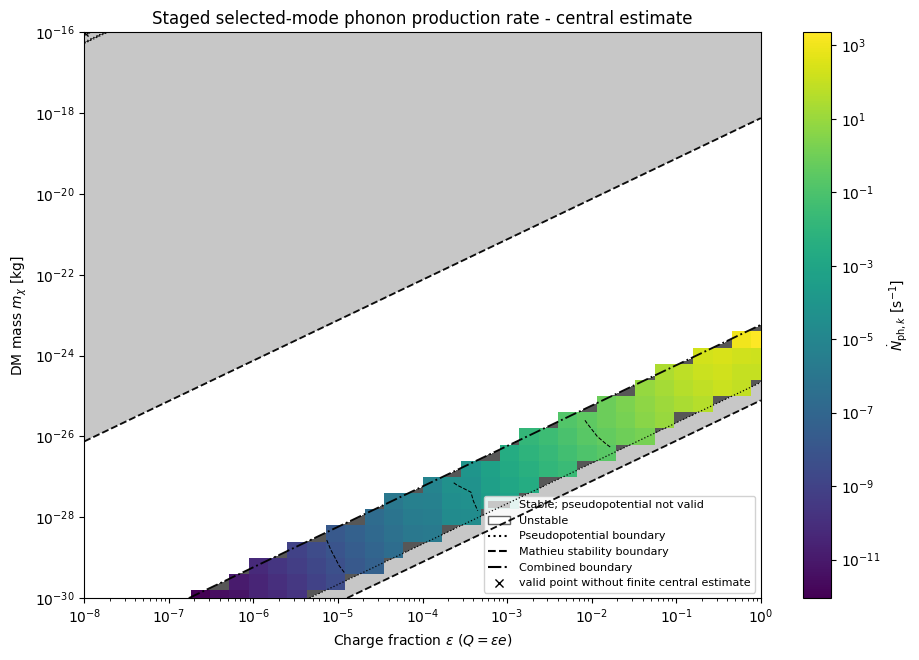

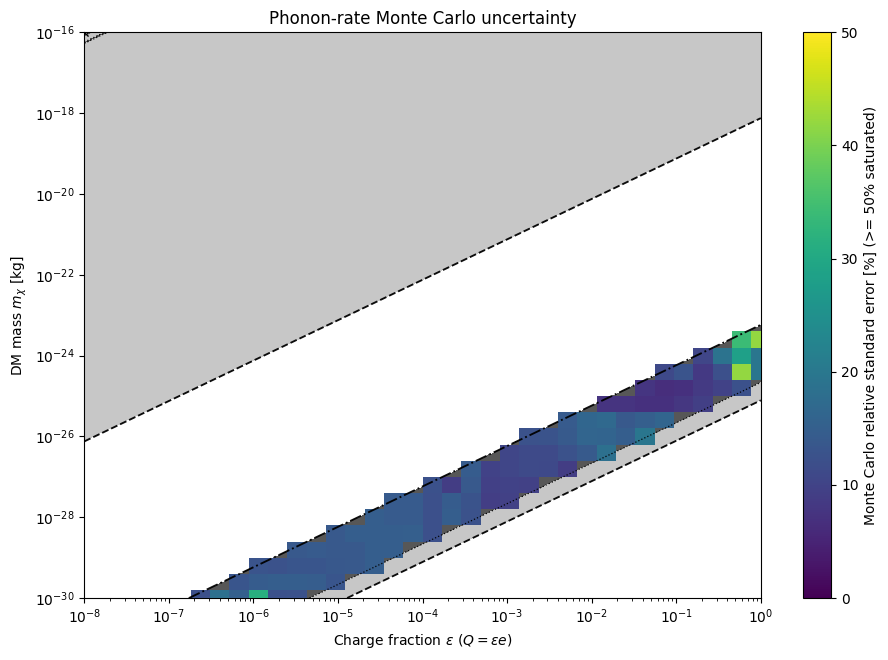

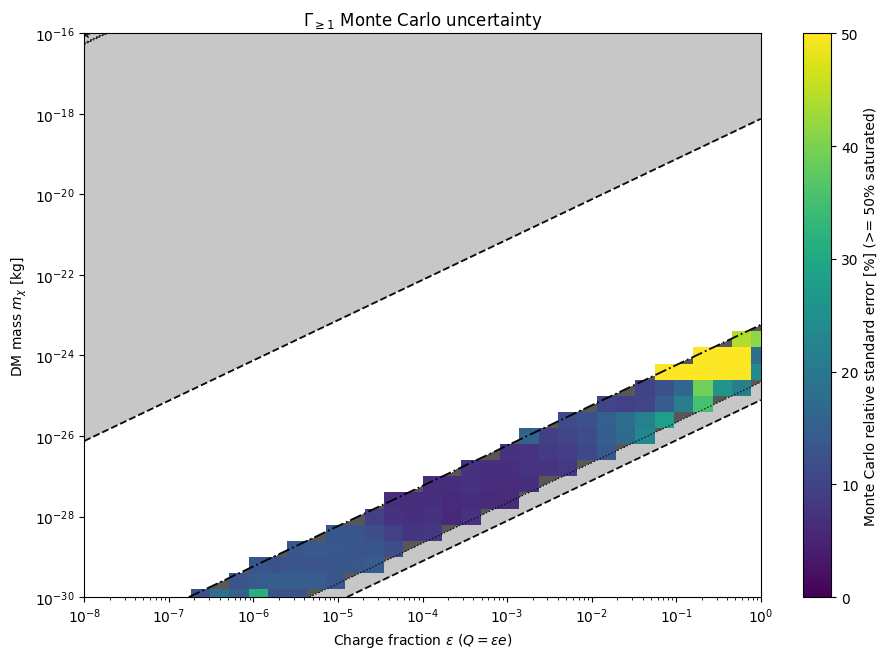

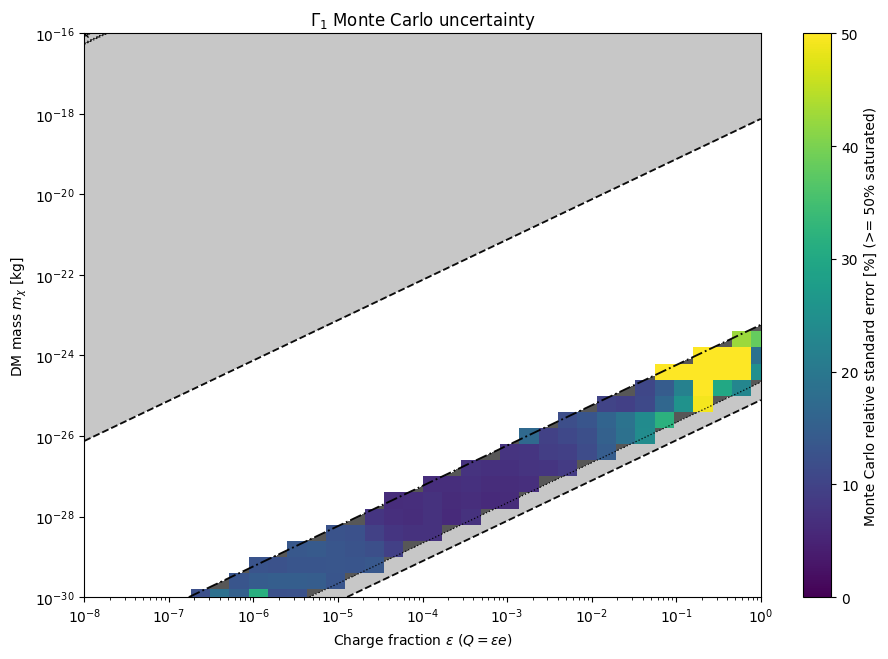

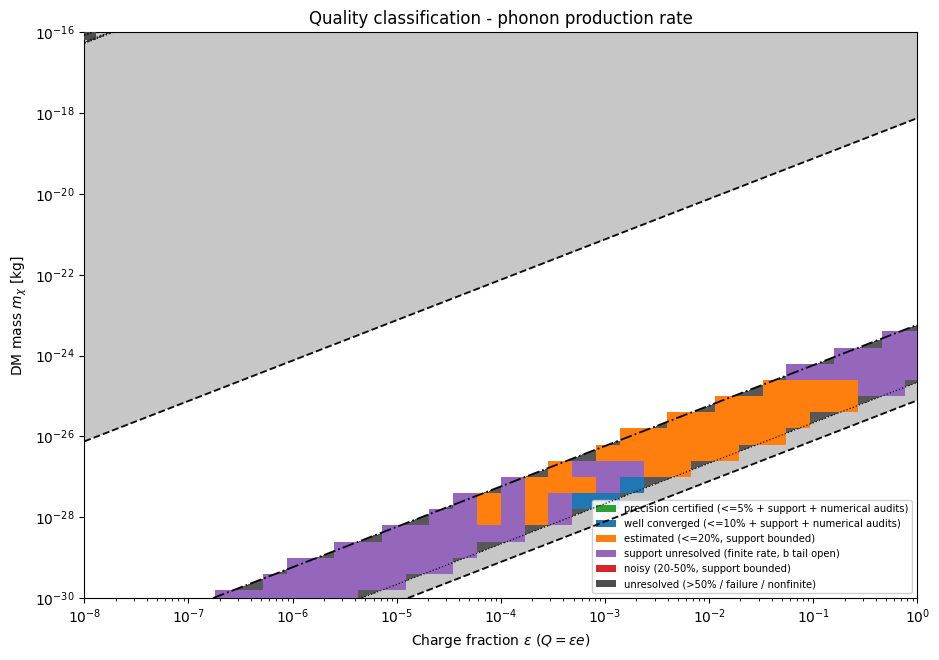

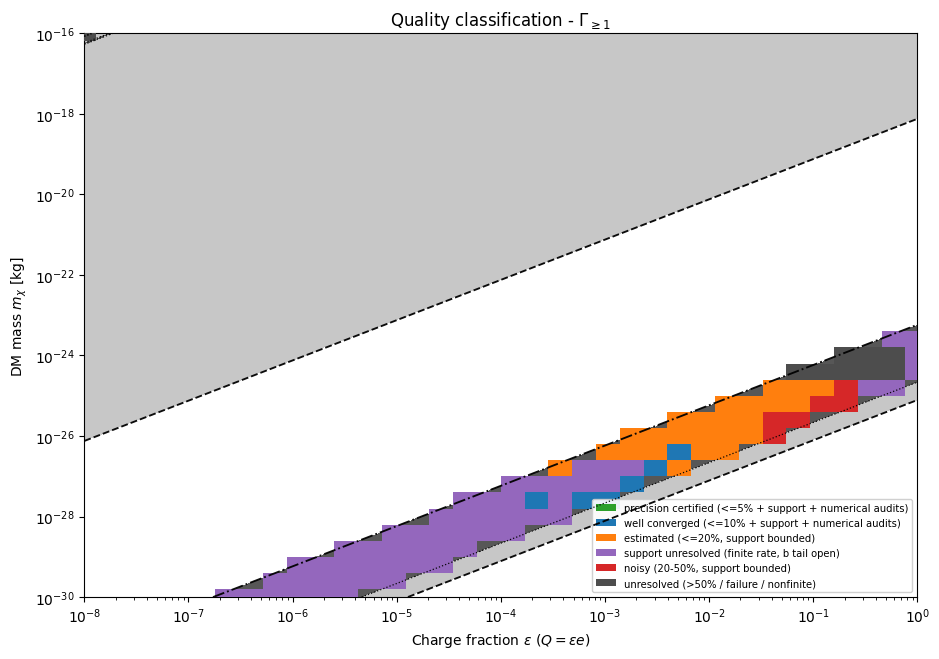

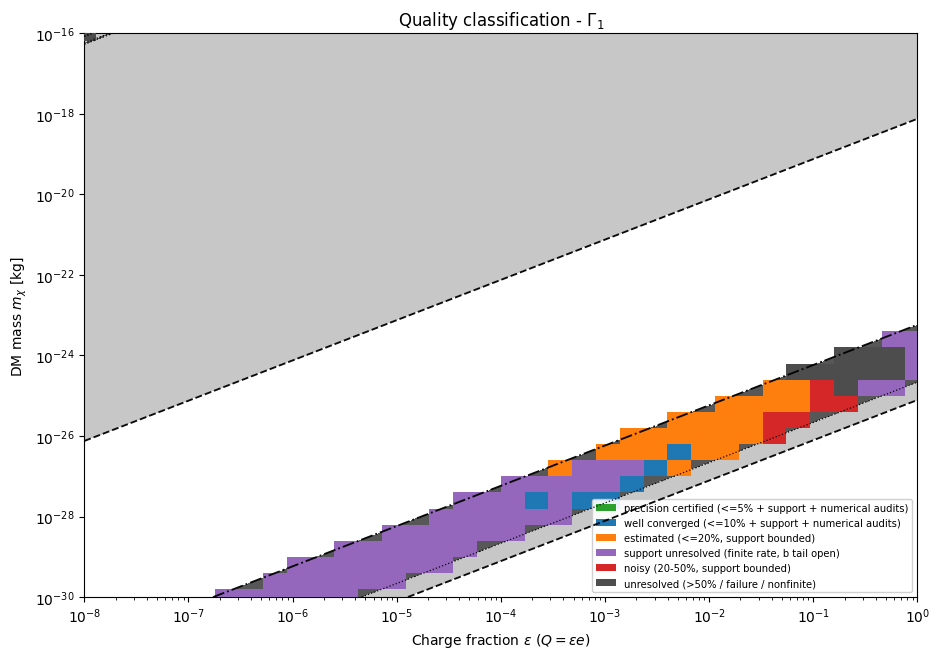

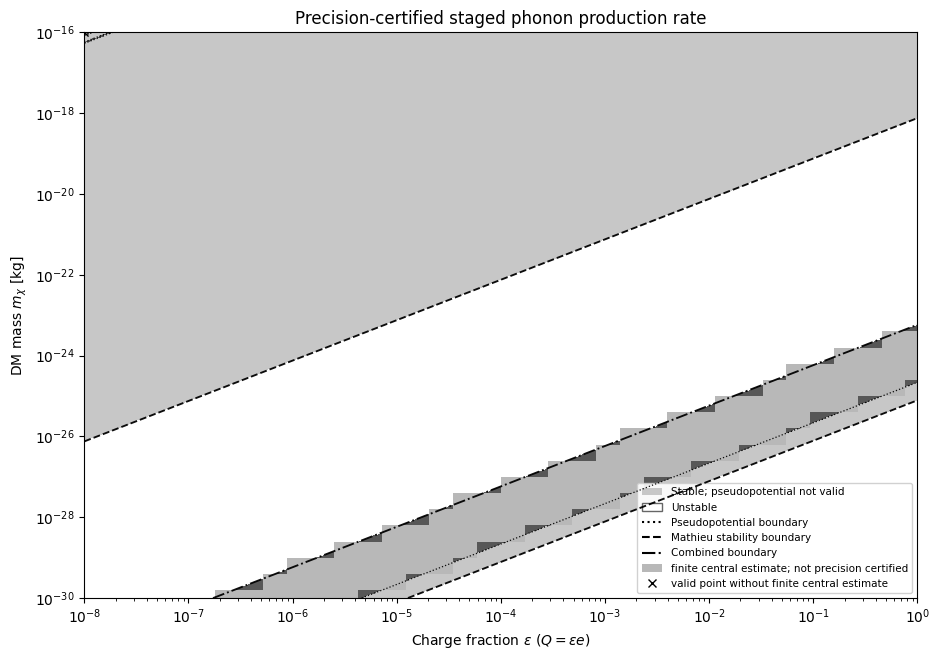

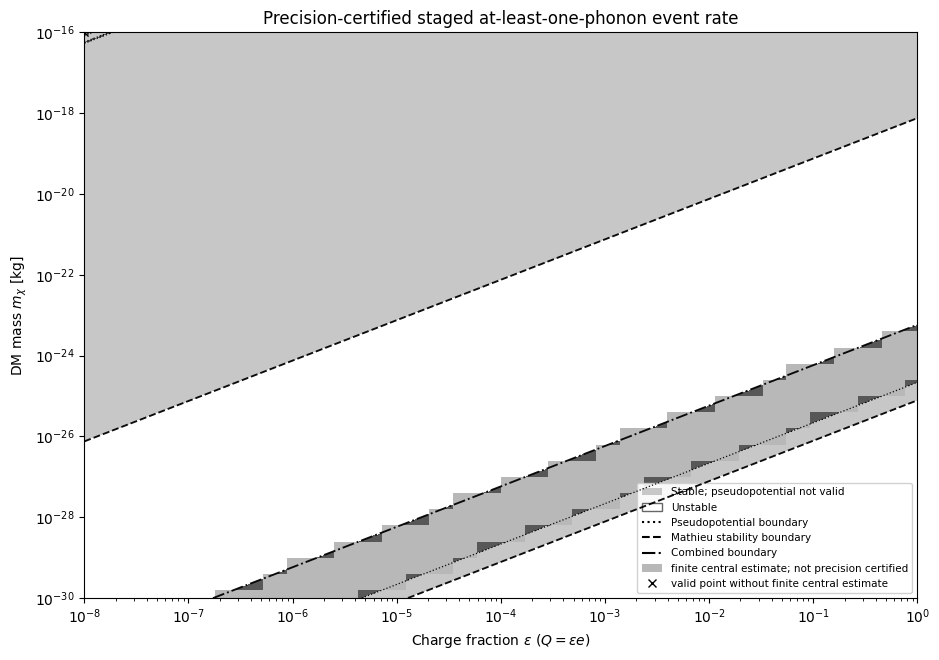

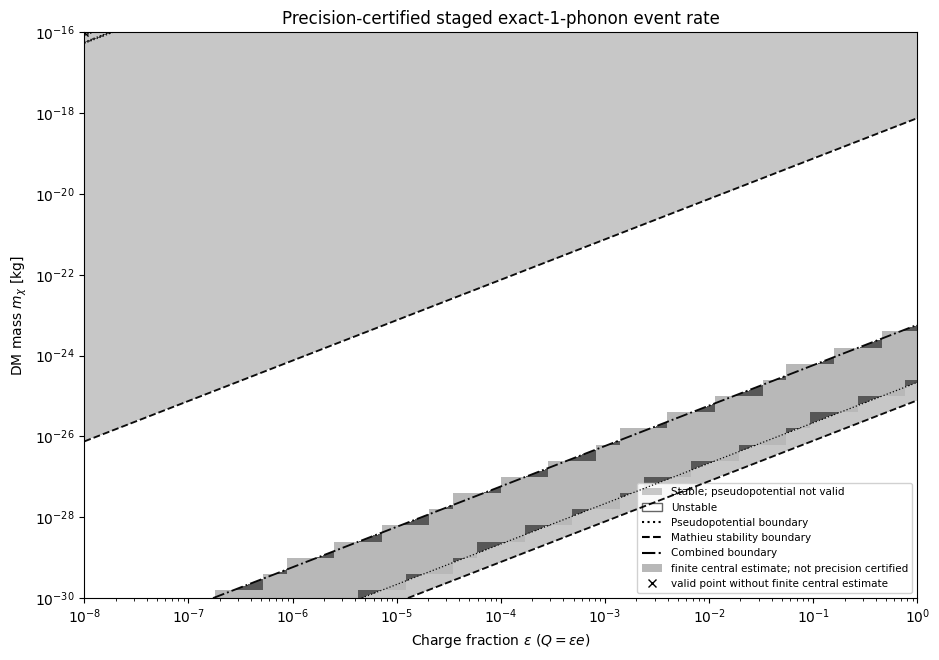

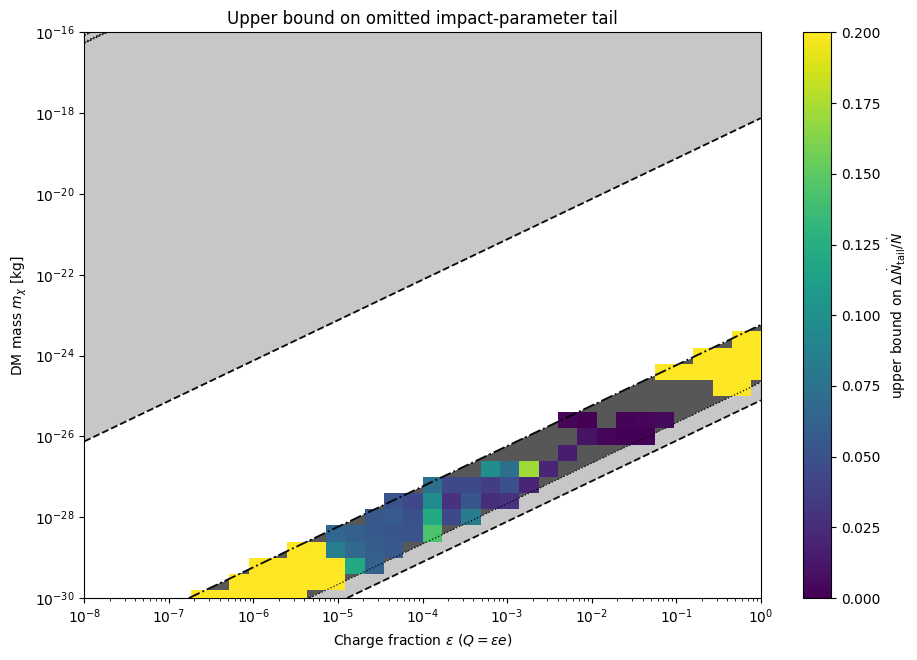

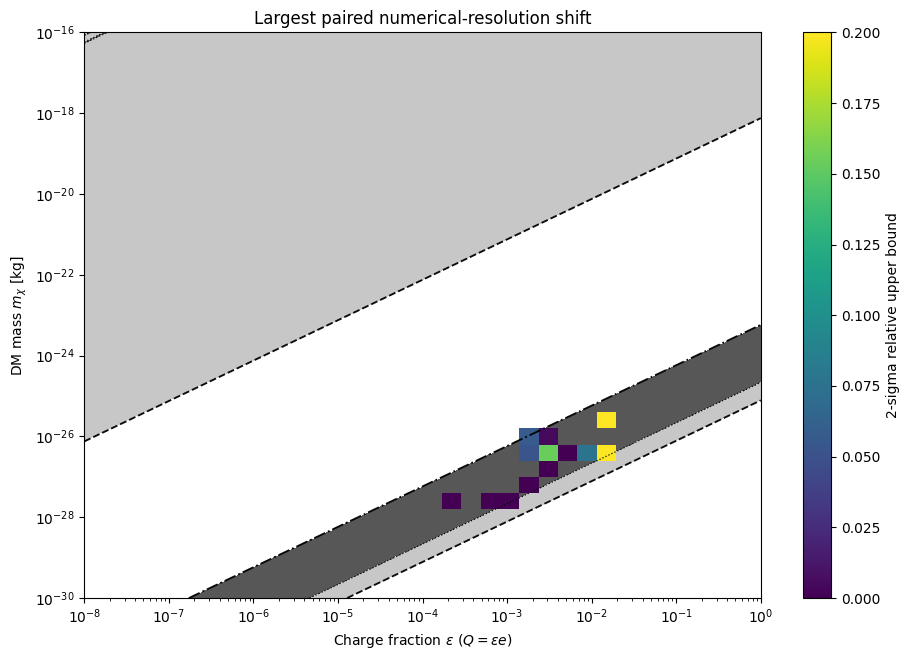

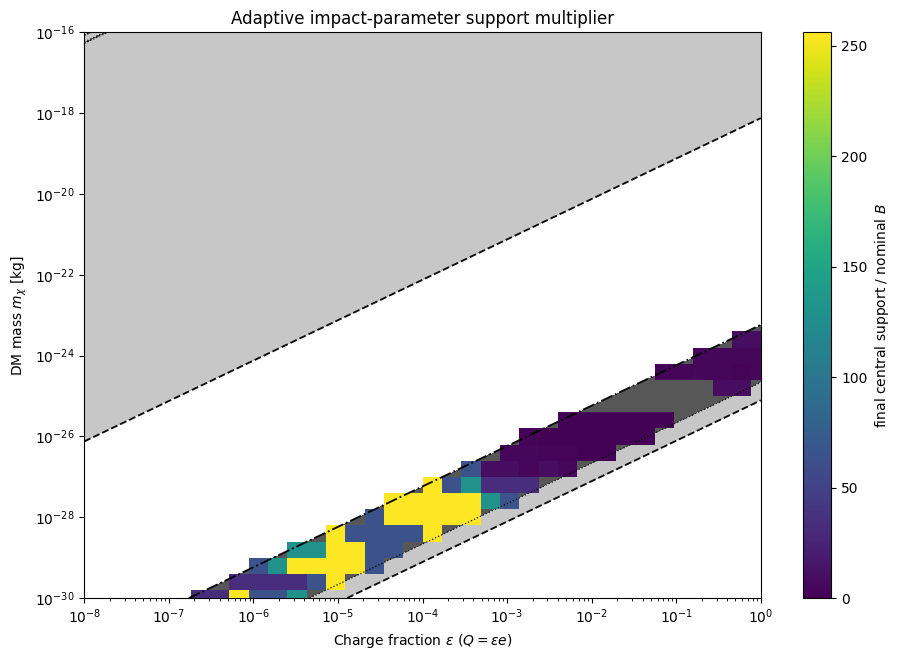

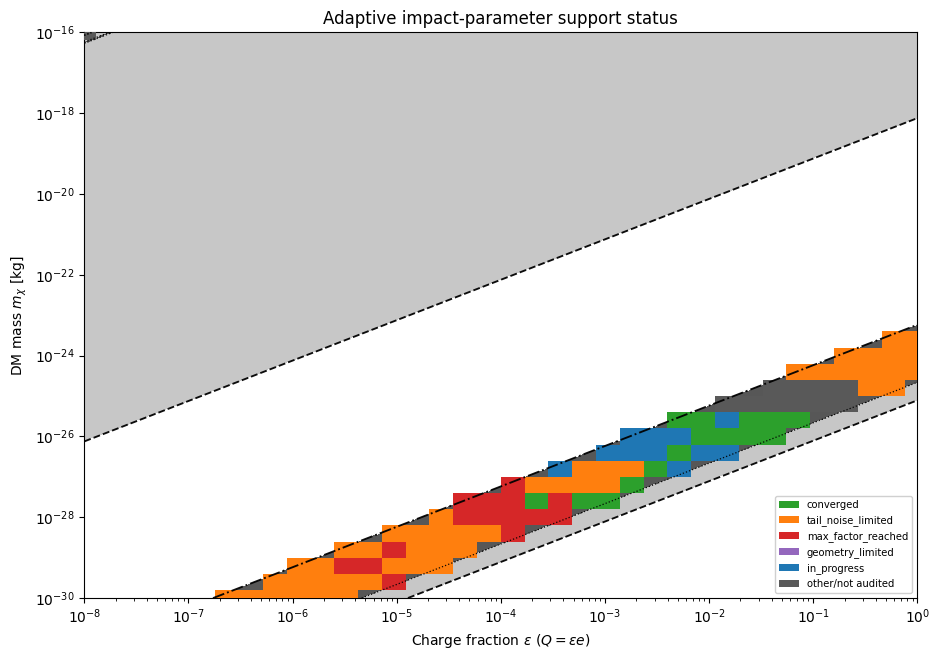

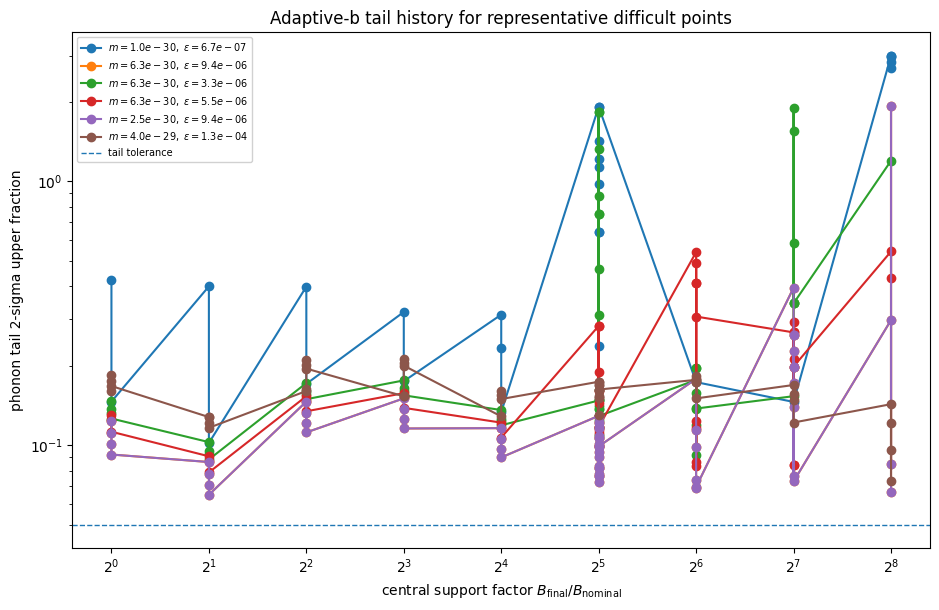

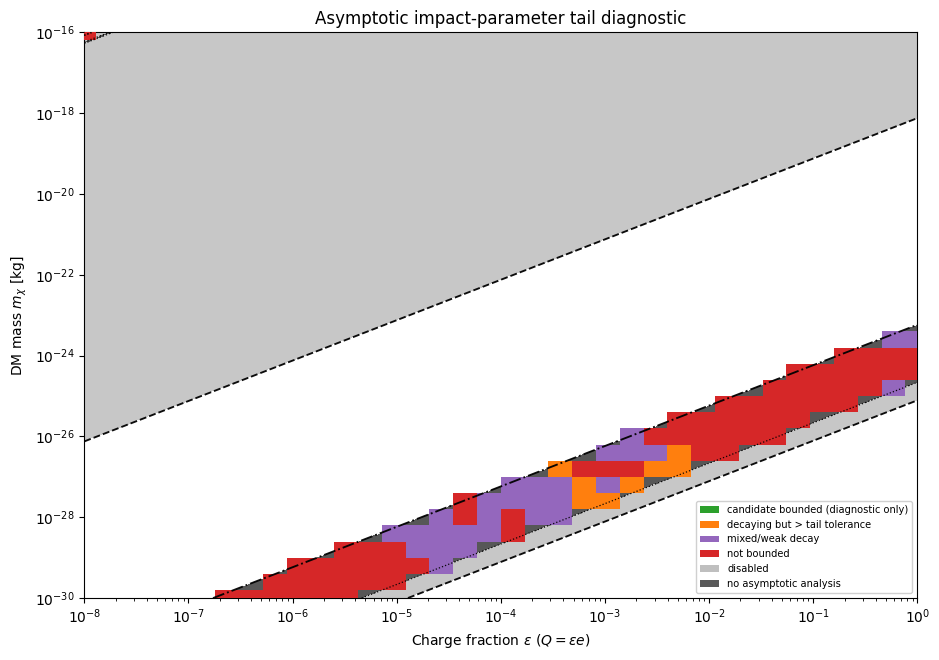

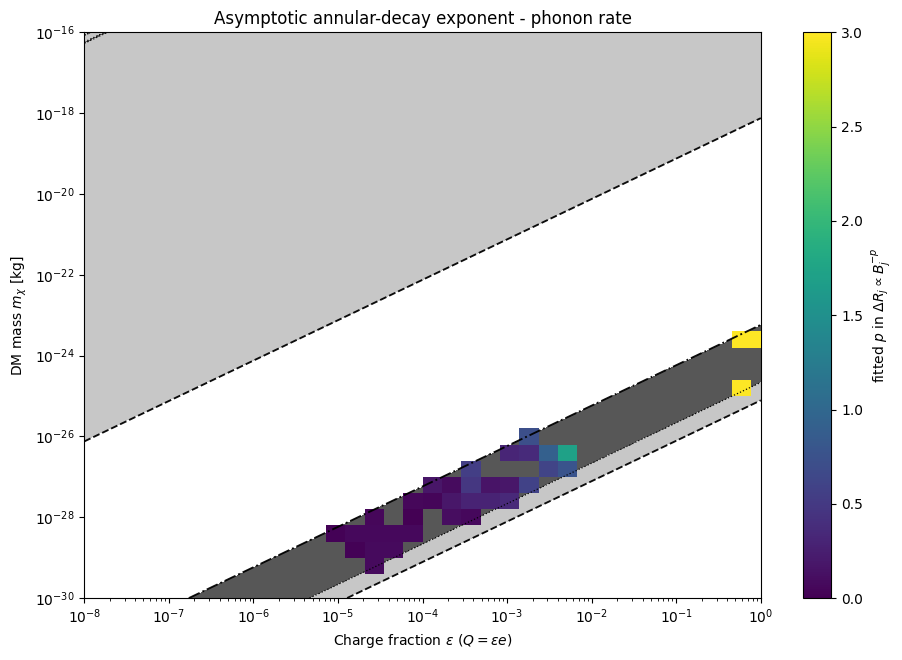

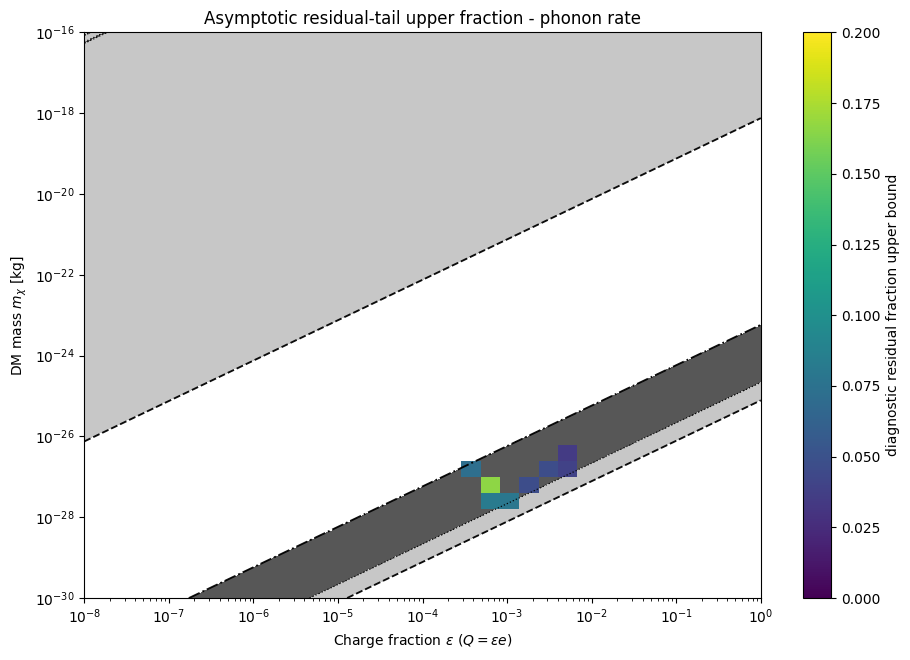

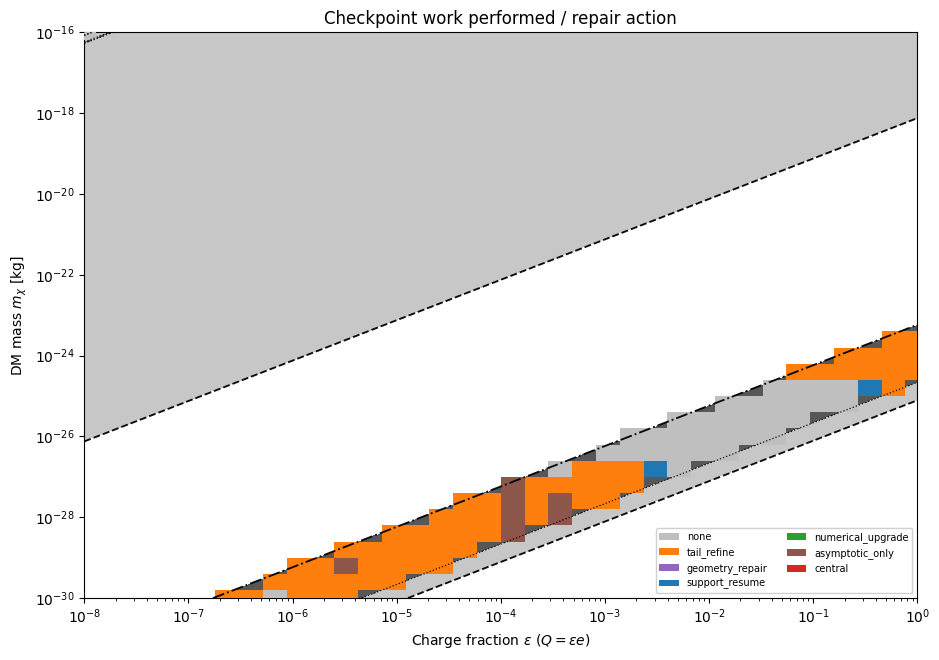

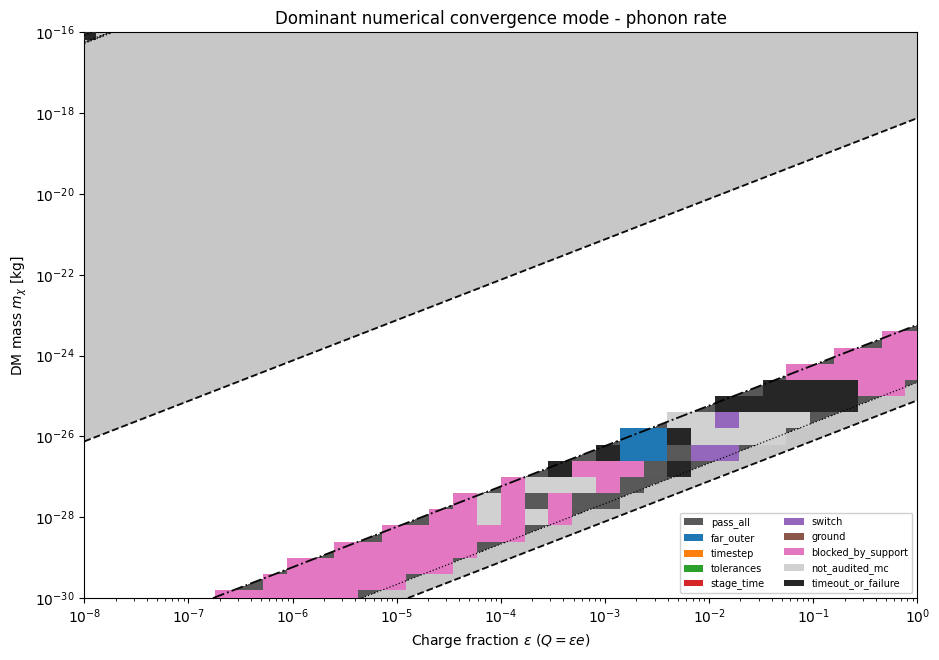

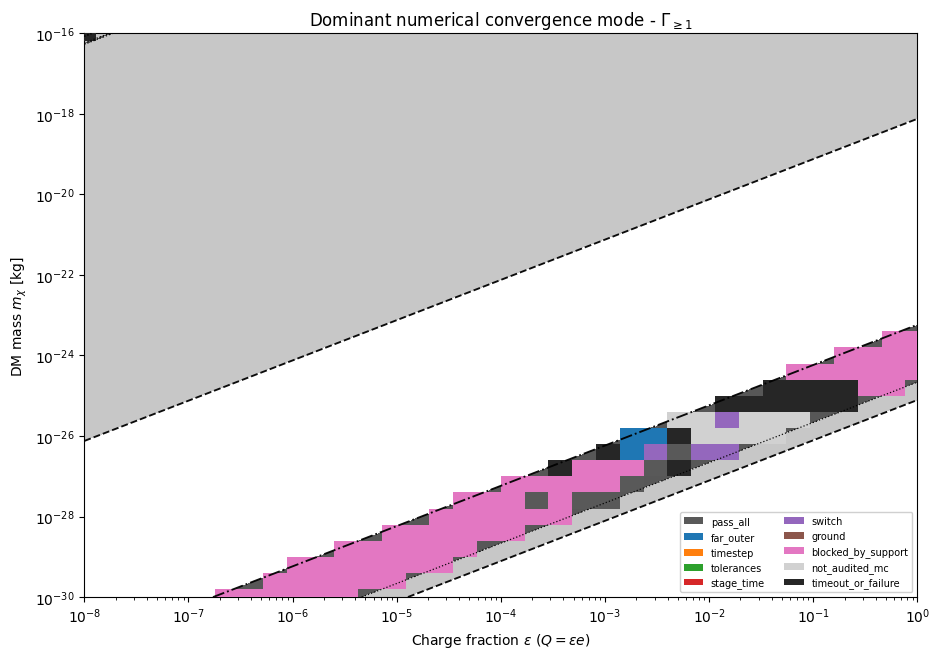

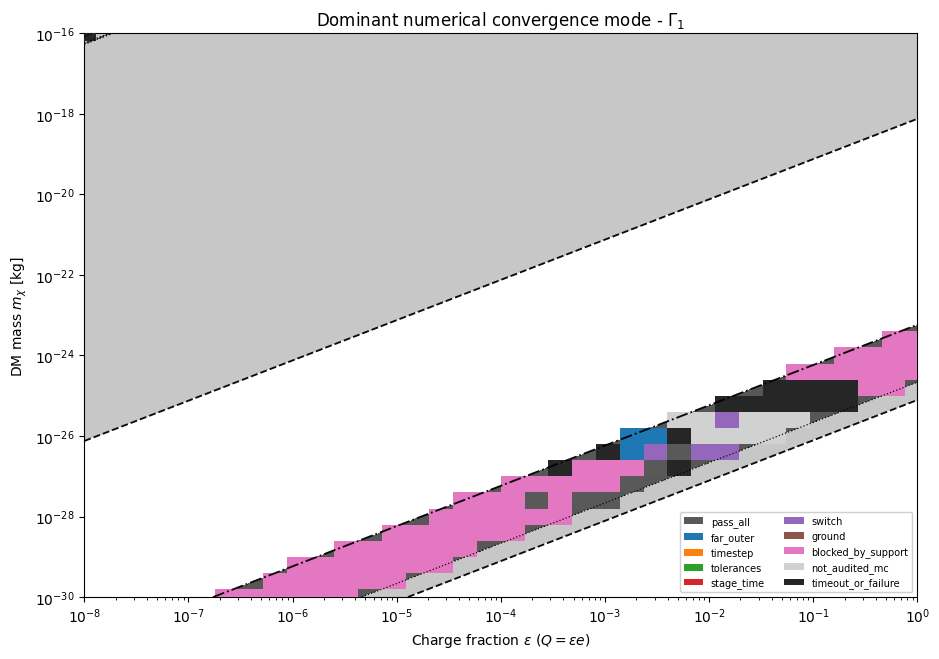

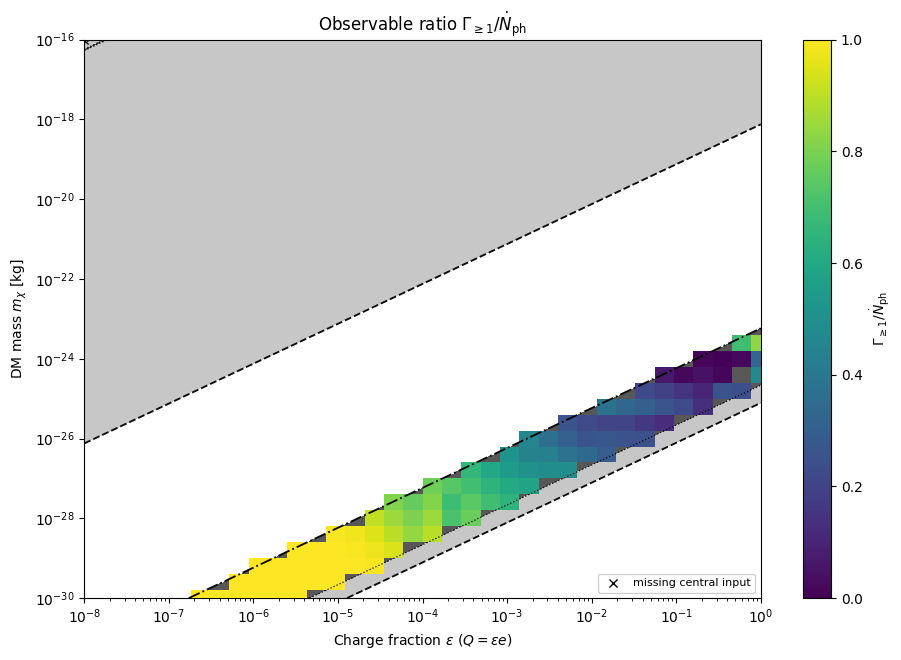

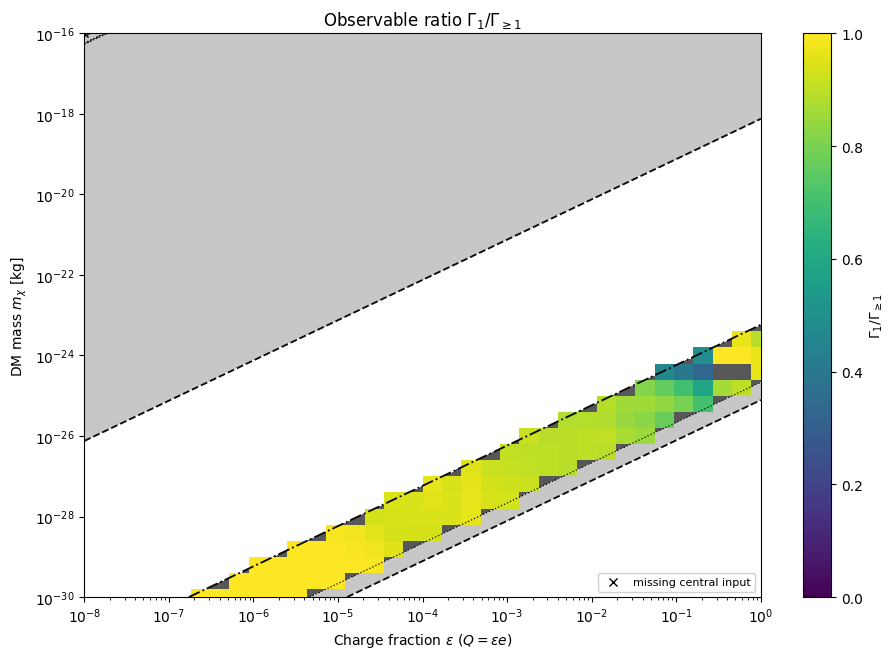

In [7]:
# -------------------------------------------------------------------------
# A. ACTUAL CENTRAL RATE MAPS - do not blank finite estimates just because
#    they miss the 5% precision-certification threshold.
# -------------------------------------------------------------------------
plot_metric(audit_df, cfg, "phonon_rate_s",
            "Staged selected-mode phonon production rate - central estimate",
            r"$\dot N_{\mathrm{ph},k}$ [s$^{-1}$]",
            OUTPUT / "staged_actual_phonon_rate.png")
plot_metric(audit_df, cfg, "event_rate_ge1_s",
            "Staged at-least-one-phonon event rate - central estimate",
            r"$\Gamma_{\geq1,k}$ [s$^{-1}$]",
            OUTPUT / "staged_actual_gamma_ge1.png")
plot_metric(audit_df, cfg, "event_rate_exact_M_s",
            f"Staged exact-{cfg.exact_phonon_number}-phonon event rate - central estimate",
            rf"$\Gamma_{{{cfg.exact_phonon_number},k}}$ [s$^{{-1}}$]",
            OUTPUT / f"staged_actual_gamma_M{cfg.exact_phonon_number}.png")
# Backward-compatible main heatmap now shows the actual central estimate.
plot_metric(audit_df, cfg, "phonon_rate_s",
            "Staged selected-mode phonon production rate - central estimate",
            r"$\dot N_{\mathrm{ph},k}$ [s$^{-1}$]",
            OUTPUT / "staged_heatmap.png")

# -------------------------------------------------------------------------
# B. MONTE CARLO UNCERTAINTY MAPS
# -------------------------------------------------------------------------
plot_relative_error(audit_df, cfg, "phonon_mc_rel_se",
                    "Phonon-rate Monte Carlo uncertainty",
                    OUTPUT / "staged_error_phonon_mc_rel_se.png",
                    cap_pct=100.0 * conv.noisy_rel_se)
plot_relative_error(audit_df, cfg, "ge1_mc_rel_se",
                    r"$\Gamma_{\geq1}$ Monte Carlo uncertainty",
                    OUTPUT / "staged_error_gamma_ge1_mc_rel_se.png",
                    cap_pct=100.0 * conv.noisy_rel_se)
plot_relative_error(audit_df, cfg, "exact_M_mc_rel_se",
                    rf"$\Gamma_{{{cfg.exact_phonon_number}}}$ Monte Carlo uncertainty",
                    OUTPUT / f"staged_error_gamma_M{cfg.exact_phonon_number}_mc_rel_se.png",
                    cap_pct=100.0 * conv.noisy_rel_se)

# -------------------------------------------------------------------------
# C. SIX-LEVEL QUALITY CLASSIFICATION MAPS
# -------------------------------------------------------------------------
plot_classification(audit_df, cfg, "phonon_class_code",
                    "Quality classification - phonon production rate",
                    OUTPUT / "staged_classification_phonon.png")
plot_classification(audit_df, cfg, "ge1_class_code",
                    r"Quality classification - $\Gamma_{\geq1}$",
                    OUTPUT / "staged_classification_gamma_ge1.png")
plot_classification(audit_df, cfg, "exact_M_class_code",
                    rf"Quality classification - $\Gamma_{{{cfg.exact_phonon_number}}}$",
                    OUTPUT / f"staged_classification_gamma_M{cfg.exact_phonon_number}.png")

# -------------------------------------------------------------------------
# D. STRICT PRECISION-CERTIFIED MAPS. Finite non-certified points are gray;
#    black x markers mean genuinely missing central estimates only.
# -------------------------------------------------------------------------
plot_precision_certified_metric(audit_df, cfg, "phonon_rate_s", "phonon_class_code",
            "Precision-certified staged phonon production rate",
            r"$\dot N_{\mathrm{ph},k}$ [s$^{-1}$]",
            OUTPUT / "staged_reliable_phonon_rate.png")
plot_precision_certified_metric(audit_df, cfg, "event_rate_ge1_s", "ge1_class_code",
            "Precision-certified staged at-least-one-phonon event rate",
            r"$\Gamma_{\geq1,k}$ [s$^{-1}$]",
            OUTPUT / "staged_reliable_gamma_ge1.png")
plot_precision_certified_metric(audit_df, cfg, "event_rate_exact_M_s", "exact_M_class_code",
            f"Precision-certified staged exact-{cfg.exact_phonon_number}-phonon event rate",
            rf"$\Gamma_{{{cfg.exact_phonon_number},k}}$ [s$^{{-1}}$]",
            OUTPUT / f"staged_reliable_gamma_M{cfg.exact_phonon_number}.png")

# Additional detailed convergence diagnostics.
plot_convergence_quantity(audit_df, cfg, "b_tail_phonon_fraction_upper",
                          "Upper bound on omitted impact-parameter tail",
                          r"upper bound on $\Delta\dot N_{\rm tail}/\dot N$",
                          OUTPUT / "staged_convergence_btail_phonon.png",
                          vmax=max(0.20, conv.b_tail_fraction_tol * 3))
if "max_numerical_phonon_relative_upper" in audit_df:
    plot_convergence_quantity(audit_df, cfg, "max_numerical_phonon_relative_upper",
                              "Largest paired numerical-resolution shift",
                              "2-sigma relative upper bound",
                              OUTPUT / "staged_convergence_numerical_phonon.png",
                              vmax=max(0.20, conv.numerical_rel_tol * 3))


# Adaptive-support size itself: 1 means the original Rutherford B was enough;
# 2,4,8,... mean successively enlarged central support.
if "adaptive_bmax_factor" in audit_df:
    plot_convergence_quantity(audit_df, cfg, "adaptive_bmax_factor",
                              "Adaptive impact-parameter support multiplier",
                              r"final central support / nominal $B$",
                              OUTPUT / "staged_adaptive_bmax_factor.png",
                              vmax=max(4.0, float(pd.to_numeric(audit_df["adaptive_bmax_factor"], errors="coerce").max())))

plot_support_status(audit_df, cfg, OUTPUT / "staged_adaptive_bmax_status.png")
if "tail_history_df" in globals() and not tail_history_df.empty:
    plot_tail_history_representatives(tail_history_df, audit_df, OUTPUT / "staged_adaptive_bmax_tail_history_representatives.png")

# Asymptotic diagnostics use stored octave history and are intentionally
# diagnostic-only: they do not turn an open support point into a certified one.
plot_asymptotic_status(audit_df, cfg, OUTPUT / "staged_asymptotic_tail_status.png")
if "asymptotic_phonon_exponent_p" in audit_df.columns:
    plot_convergence_quantity(audit_df, cfg, "asymptotic_phonon_exponent_p",
                              "Asymptotic annular-decay exponent - phonon rate",
                              r"fitted $p$ in $\Delta R_j\propto B_j^{-p}$",
                              OUTPUT / "staged_asymptotic_tail_exponent_phonon.png", vmax=3.0)
if "asymptotic_phonon_remainder_fraction_upper" in audit_df.columns:
    plot_convergence_quantity(audit_df, cfg, "asymptotic_phonon_remainder_fraction_upper",
                              "Asymptotic residual-tail upper fraction - phonon rate",
                              "diagnostic residual fraction upper bound",
                              OUTPUT / "staged_asymptotic_tail_remainder_phonon.png", vmax=0.20)
plot_repair_action(audit_df, cfg, OUTPUT / "staged_checkpoint_repair_action.png")

# Dominant numerical-failure mode, separately for each observable.
plot_numerical_failure_mode(audit_df, cfg, "dominant_numerical_phonon_code",
                            "Dominant numerical convergence mode - phonon rate",
                            OUTPUT / "staged_numerical_failure_phonon.png")
plot_numerical_failure_mode(audit_df, cfg, "dominant_numerical_ge1_code",
                            r"Dominant numerical convergence mode - $\Gamma_{\geq1}$",
                            OUTPUT / "staged_numerical_failure_gamma_ge1.png")
plot_numerical_failure_mode(audit_df, cfg, "dominant_numerical_exact_M_code",
                            rf"Dominant numerical convergence mode - $\Gamma_{{{cfg.exact_phonon_number}}}$",
                            OUTPUT / f"staged_numerical_failure_gamma_M{cfg.exact_phonon_number}.png")

# Observable-ratio maps.  Both ratios are bounded by 1 for the coherent-state
# observables used here; values near 1 diagnose weak/single-phonon excitation.
plot_observable_ratio(audit_df, cfg, "event_rate_ge1_s", "phonon_rate_s",
                      r"Observable ratio $\Gamma_{\geq1}/\dot N_{\rm ph}$",
                      r"$\Gamma_{\geq1}/\dot N_{\rm ph}$",
                      OUTPUT / "staged_ratio_gamma_ge1_to_phonon.png")
plot_observable_ratio(audit_df, cfg, "event_rate_exact_M_s", "event_rate_ge1_s",
                      rf"Observable ratio $\Gamma_{{{cfg.exact_phonon_number}}}/\Gamma_{{\geq1}}$",
                      rf"$\Gamma_{{{cfg.exact_phonon_number}}}/\Gamma_{{\geq1}}$",
                      OUTPUT / f"staged_ratio_gamma_M{cfg.exact_phonon_number}_to_ge1.png")


## 6. Staged / screening comparison

The comparison CSV now uses the **actual staged central estimates** rather than deleting every point that misses 5% precision. Interpret the ratio together with the staged uncertainty and classification maps. The strict precision-certified-only table remains available separately.


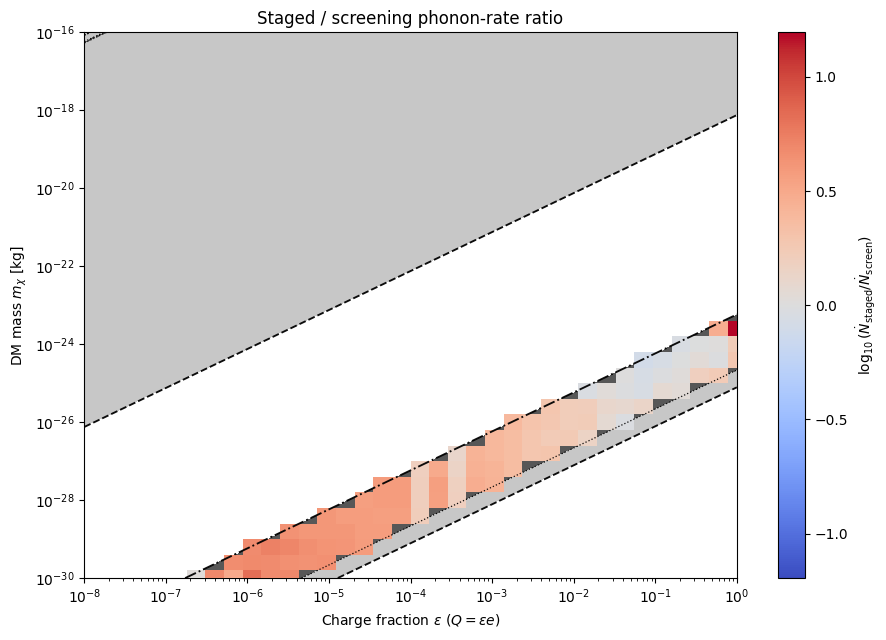

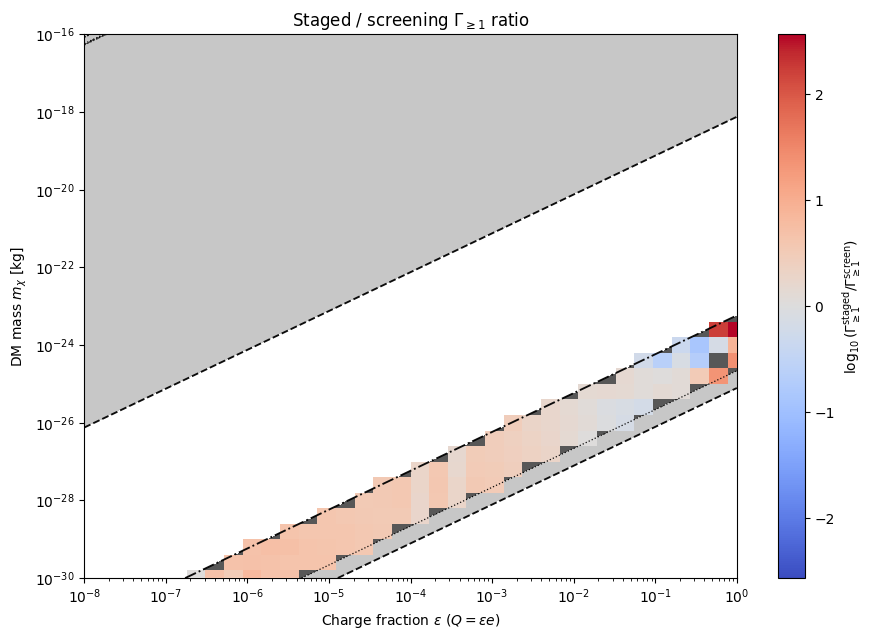

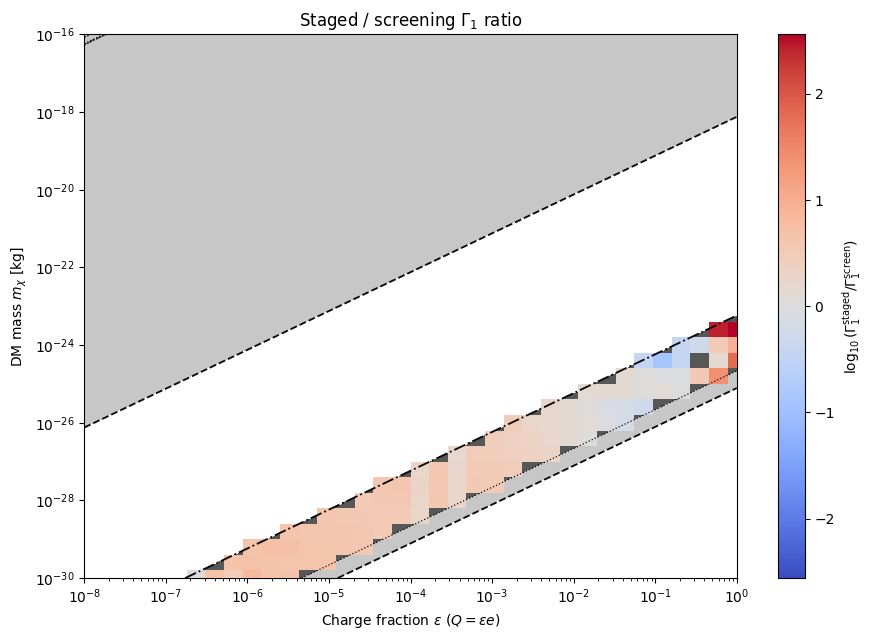

In [8]:
def plot_ratio_map(comparison, ratio_column, label, title, path):
    common = comparison.dropna(subset=[ratio_column]).copy()
    common = common[np.isfinite(common[ratio_column]) & (common[ratio_column] > 0)]
    if common.empty:
        print("No finite common points for", ratio_column)
        return
    masses = np.sort(common.m_dm_kg.unique())
    eps = np.sort(common.eps.unique())
    R = (common.pivot(index="eps", columns="m_dm_kg", values=ratio_column)
         .reindex(index=eps, columns=masses).to_numpy().T)
    logR = np.log10(np.where(R > 0, R, np.nan))
    vmax = max(0.5, float(np.nanmax(np.abs(logR)))) if np.isfinite(logR).any() else 1.0
    fig, ax = plt.subplots(figsize=(9.2, 6.5))
    _draw_reference_background(ax, cfg)
    im = ax.pcolormesh(_log_edges(eps), _log_edges(masses), logR, shading="flat",
                       cmap="coolwarm", norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax), zorder=3)
    fig.colorbar(im, ax=ax).set_label(label)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(cfg.eps_min, cfg.eps_max); ax.set_ylim(cfg.m_min_kg, cfg.m_max_kg)
    ax.set_xlabel(r"Charge fraction $\epsilon$ ($Q=\epsilon e$)")
    ax.set_ylabel(r"DM mass $m_\chi$ [kg]")
    ax.set_title(title)
    fig.tight_layout(); fig.savefig(path, dpi=180); plt.show()

screen_path = OUTPUT / "screening_event_rate.csv"
if screen_path.exists():
    screening_df = pd.read_csv(screen_path)
    comparison = compare_frames(audit_df, screening_df)
    comparison.to_csv(OUTPUT / "staged_vs_screening.csv", index=False)
    plot_ratio_map(comparison, "phonon_rate_s_ratio_staged_over_screening",
                   r"$\log_{10}(\dot N_{\rm staged}/\dot N_{\rm screen})$",
                   "Staged / screening phonon-rate ratio",
                   OUTPUT / "staged_vs_screening_phonon_ratio.png")
    plot_ratio_map(comparison, "event_rate_ge1_s_ratio_staged_over_screening",
                   r"$\log_{10}(\Gamma_{\geq1}^{\rm staged}/\Gamma_{\geq1}^{\rm screen})$",
                   r"Staged / screening $\Gamma_{\geq1}$ ratio",
                   OUTPUT / "staged_vs_screening_gamma_ge1_ratio.png")
    plot_ratio_map(comparison, "event_rate_exact_M_s_ratio_staged_over_screening",
                   rf"$\log_{{10}}(\Gamma_{{{cfg.exact_phonon_number}}}^{{\rm staged}}/\Gamma_{{{cfg.exact_phonon_number}}}^{{\rm screen}})$",
                   rf"Staged / screening $\Gamma_{{{cfg.exact_phonon_number}}}$ ratio",
                   OUTPUT / f"staged_vs_screening_gamma_M{cfg.exact_phonon_number}_ratio.png")
else:
    print("Run the screening notebook first.")


## 7. How to interpret the six quality classes

The central rate, the MC error, support status, and classification are separate pieces of information. `precision_certified` is the strict convergence claim; `well_converged` is a strong quantitative result with up to 10% MC error and passed support/numerical audits; `estimated` has bounded impact-parameter support and <=20% MC error but is not fully numerically certified; `support_unresolved` has a finite central estimate but the outer-$b$ integral is not yet bounded; `noisy` has bounded support but 20--50% MC error; and `unresolved` should not be used as a numerical prediction.

A failed $b$-support audit no longer produces an ordinary `estimated` label. It produces `support_unresolved`, because omitted phase space is qualitatively different from sampling noise. Numerical audits are intentionally blocked until the support audit passes. A bounded-support point can still be `estimated` when its MC error is <=20% but the numerical audit is absent or incomplete. The `*_classification_reason`, `reliability_failures`, `b_tail_*`, and numerical-audit columns in `staged_event_rate_classified.csv` record the reason.

These quality classes describe **numerical/statistical confidence in the stated staged model**. They do not remove the separate systematic uncertainty associated with the phenomenological copper-transport model.
